# Анализ данных по снижению покуптельской активности

В настоящей работе будет рассмотрены данные о деятельности интернет-магазина с целью разработать модель, которая предскажет вероятность снижения покупательской активности, а также, основываясь на предсказании модели и данных о прибыльности выделить сегменты покупателей и разработать для них персонализированные предложения.

In [1]:
!pip install shap

In [2]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.metrics import confusion_matrix
import shap

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Загрузка данных

In [7]:
market_file = pd.read_csv('/Users/Larisa/Documents/first_project/market_file.csv')

In [8]:
market_file.head().T

,0,1,2,3,4
id,215348,215349,215350,215351,215352
Покупательская активность,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась
Тип сервиса,премиум,премиум,стандартт,стандартт,стандартт
Разрешить сообщать,да,да,нет,да,нет
Маркет_актив_6_мес,3.4,4.4,4.9,3.2,5.1
Маркет_актив_тек_мес,5,4,3,5,3
Длительность,121,819,539,896,1064
Акционные_покупки,0.0,0.75,0.14,0.99,0.94
Популярная_категория,Товары для детей,Товары для детей,Домашний текстиль,Товары для детей,Товары для детей
Средний_просмотр_категорий_за_визит,6,4,5,5,3


In [9]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [10]:
market_money = pd.read_csv('/Users/Larisa/Documents/first_project/market_money.csv')

In [11]:
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [12]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [13]:
market_time = pd.read_csv('/Users/Larisa/Documents/first_project/market_time.csv')

In [14]:
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [15]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [16]:
money = pd.read_csv('/Users/Larisa/Documents/first_project/money.csv')

In [17]:
money.head()

,id;Прибыль
215348;0,98.0
215349;4,16.0
215350;3,13.0
215351;4,87.0
215352;4,21.0


In [18]:
money = pd.read_csv('/Users/Larisa/Documents/first_project/money.csv', sep=';', decimal=',')

In [19]:
money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [20]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Для рассмотрения поставленной задачи были загружены:  
- данные о деятельности интернет-магазина с информацией по поведению покупателей на сайте (сколько страниц, категорий товаров покупатель просматривает за визит, ошибки сайта), информацией по потребительскому поведению (любимые категории, акционные покупки, число неоплаченных продуктов к корзине), данные о маркетиноговой активности интернет-магазина (за 6 месяцев и за текущий),   
- данные сколько времени провел покупатель на сайте за текущий и за предыдущий месяц,   
- данные о прибыли магазина от одного клиента за три месяца,   
- данные о доходе магазина от одного клиента за текущиЙ, предыдущий и предпредыдущий месяцы.  

##  Предобработка данных


Переименуем названия столбцов в одном стиле: начинаются с маленькой буквы, соединены нижним подчеркиванием

In [21]:
market_file = market_file.rename(columns=lambda x: x.replace(' ', '_').lower())

In [22]:
market_money = market_money.rename(columns=lambda x: x.replace(' ', '_').lower())

In [23]:
market_time = market_time.rename(columns=lambda x: x.replace(' ', '_').lower())

In [24]:
money = money.rename(columns=lambda x: x.replace(' ', '_').lower())

Проверяем на пропуски

In [25]:
market_file.isna().sum()

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
dtype: int64

In [26]:
market_money.isna().sum()

id         0
период     0
выручка    0
dtype: int64

In [27]:
market_time.isna().sum()

id        0
период    0
минут     0
dtype: int64

In [28]:
money.isna().sum()

id         0
прибыль    0
dtype: int64

Ищем полные дубликаты

In [29]:
market_file.duplicated().sum()

0

In [30]:
market_money.duplicated().sum()

0

In [31]:
market_time.duplicated().sum()

0

In [32]:
money.duplicated().sum()

0

проверим категориальные данные в столбцах на уникальность (скрытые дубликаты)

In [33]:
market_file[['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']].apply(lambda x: x.unique())

покупательская_активность                         [Снизилась, Прежний уровень]
тип_сервиса                                     [премиум, стандартт, стандарт]
разрешить_сообщать                                                   [да, нет]
популярная_категория         [Товары для детей, Домашний текстиль, Косметик...
dtype: object

In [34]:
market_file['популярная_категория'].unique()

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксесуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

In [35]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].str.replace('стандартт', 'стандарт')

In [36]:
market_file['тип_сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [37]:
market_money['период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [38]:
market_time['период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [39]:
market_time['период'] = market_time['период'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')

In [40]:
market_time['период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

При загрузке и предобработке данных были переименованы столбцы в один формат, исправлены ошибки в категориальных данных для соответствия друг другу

## Исследовательский анализ данных

Целью данной работы является построить модель, которая предскажет вероятность снижения покупательской активности клиента интернет-магазина в следующие три месяца, основываясь на данных, какой доход приносил данный клиент в предыдущие три месяца. 

In [41]:
market_file.head(10).T

,0,1,2,3,4,5,6,7,8,9
id,215348,215349,215350,215351,215352,215353,215354,215355,215356,215357
покупательская_активность,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась,Снизилась
тип_сервиса,премиум,премиум,стандарт,стандарт,стандарт,стандарт,стандарт,стандарт,стандарт,стандарт
разрешить_сообщать,да,да,нет,да,нет,да,да,нет,да,да
маркет_актив_6_мес,3.4,4.4,4.9,3.2,5.1,3.3,5.1,4.7,4.2,3.9
маркет_актив_тек_мес,5,4,3,5,3,4,3,4,4,5
длительность,121,819,539,896,1064,762,431,284,192,154
акционные_покупки,0.0,0.75,0.14,0.99,0.94,0.26,0.23,0.17,0.14,0.0
популярная_категория,Товары для детей,Товары для детей,Домашний текстиль,Товары для детей,Товары для детей,Домашний текстиль,Косметика и аксесуары,Товары для детей,Косметика и аксесуары,Техника для красоты и здоровья
средний_просмотр_категорий_за_визит,6,4,5,5,3,4,2,5,2,3


In [42]:
market_file.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.0,215672.75,215997.50,216322.25,216647.00
маркет_актив_6_мес,1300.0,4.253769,1.014814,0.9,3.70,4.20,4.90,6.60
маркет_актив_тек_мес,1300.0,4.011538,0.696868,3.0,4.00,4.00,4.00,5.00
длительность,1300.0,601.898462,249.856289,110.0,405.50,606.00,806.00,1079.00
акционные_покупки,1300.0,0.319808,0.249843,0.0,0.17,0.24,0.30,0.99
средний_просмотр_категорий_за_визит,1300.0,3.270000,1.355350,1.0,2.00,3.00,4.00,6.00
неоплаченные_продукты_штук_квартал,1300.0,2.840000,1.971451,0.0,1.00,3.00,4.00,10.00
ошибка_сервиса,1300.0,4.185385,1.955298,0.0,3.00,4.00,6.00,9.00
страниц_за_визит,1300.0,8.176923,3.978126,1.0,5.00,8.00,11.00,20.00


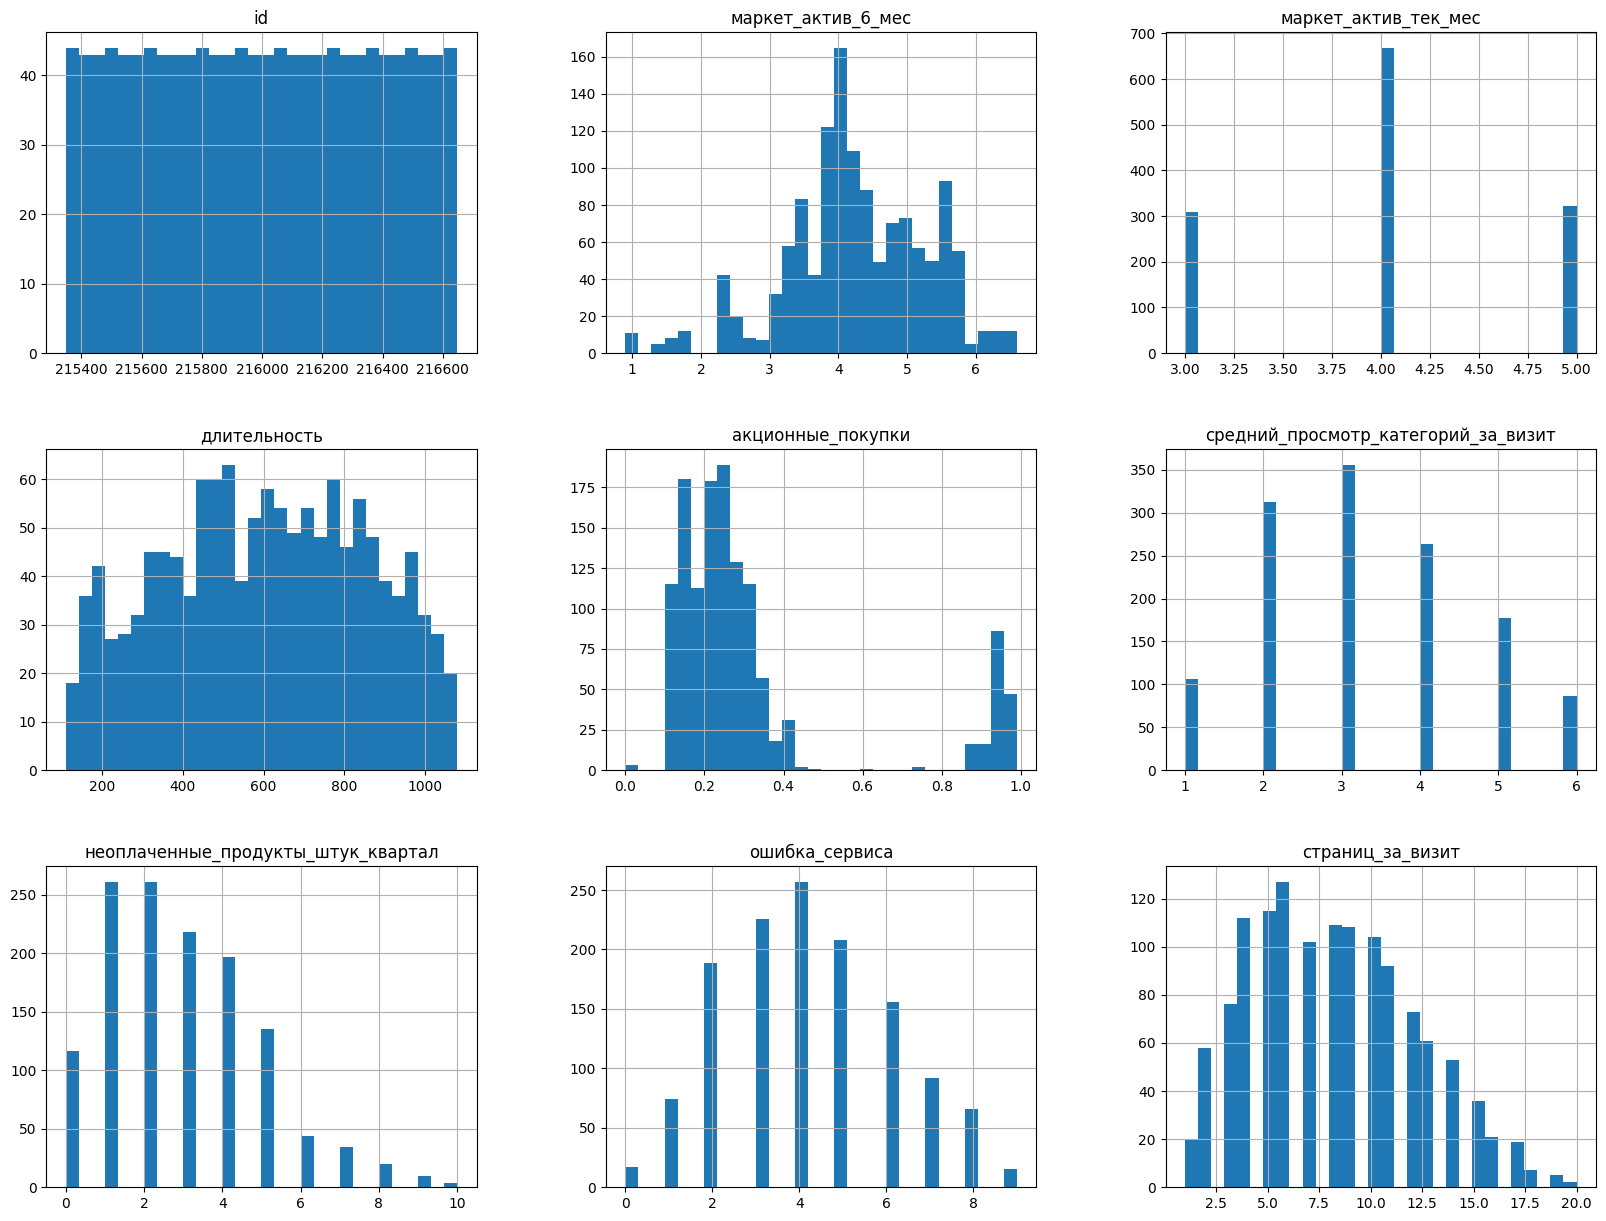

In [43]:
market_file.hist(figsize = (20, 15), bins=30)
plt.show();

Маркетинговая активность в текущем месяце чуть снизилась, по сравнению со среднемесячной активностью за последние 6 месяцев, количество маркетинговых акций на одного покупателя стало более однообразным (3, 4 или 5). При этом акционный покупки покупатели в среднем совершают 0.2-0.3 в месяц, второй пик (наполовине меньше) приходится на 2 акционную покупку в месяц. Медиана акционных покупок 0.24, а медиана маркетинговых акций за последний месяц 0.4. Соотношение среднего количества покупок к среднему количеству акций ближе, чем у медианы (что объясняется вторым пиком по количеству акционных покупок.  
Минимальная длительность регистрации на сайте - 110 дней. Нельзя говорить, что клиенты только зарегистрировались.

In [44]:
market_money.head()

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [45]:
market_money.describe()

,id,выручка
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


Посмотрим на клиентов, которые не делали покупок каждые три последних месяца


In [46]:
inactiv_clients = market_money[market_money['выручка'] == 0]
inactiv_clients

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
2,215348,предыдущий_месяц,0.0
28,215357,препредыдущий_месяц,0.0
29,215357,предыдущий_месяц,0.0
34,215359,предыдущий_месяц,0.0
35,215359,препредыдущий_месяц,0.0


Клиентов, не совершавших покупок в предпредыдущем и предыдущем месяце, только трое, при этом все из них принесли доход в текущем месяце. Исключим этих клиентов из данных для анализа.

Посмотрим на клиентов, с платежами более 100000 рублей в месяц

In [47]:
market_money_big = market_money[market_money['выручка'] >= 100000]
market_money_big.head()

,id,период,выручка
98,215380,текущий_месяц,106862.2


Такой клиент один, также уберем эти данные, чтобы они не искажали общую картину

In [48]:
market_money = market_money[~market_money['id'].isin([215380, 215348, 215357, 215359])]

In [49]:
market_money['выручка'].describe()

count    3888.000000
mean     5007.255658
std       679.193461
min      2758.700000
25%      4591.950000
50%      4959.000000
75%      5363.000000
max      7799.400000
Name: выручка, dtype: float64

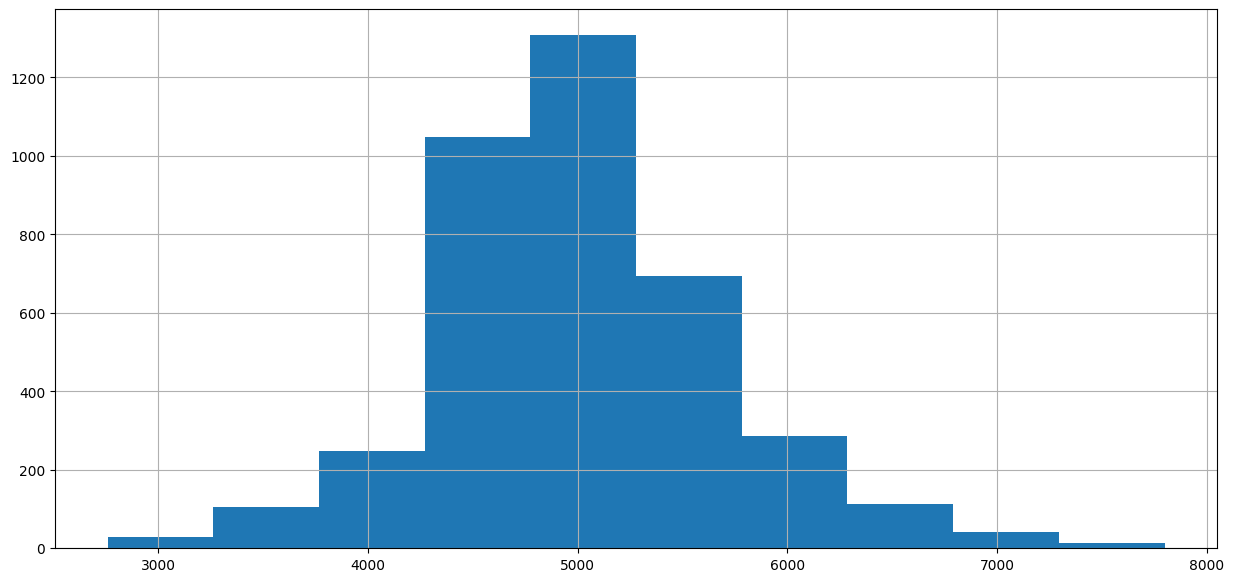

In [50]:
market_money['выручка'].hist(figsize = (15, 7), bins=10)
plt.show();

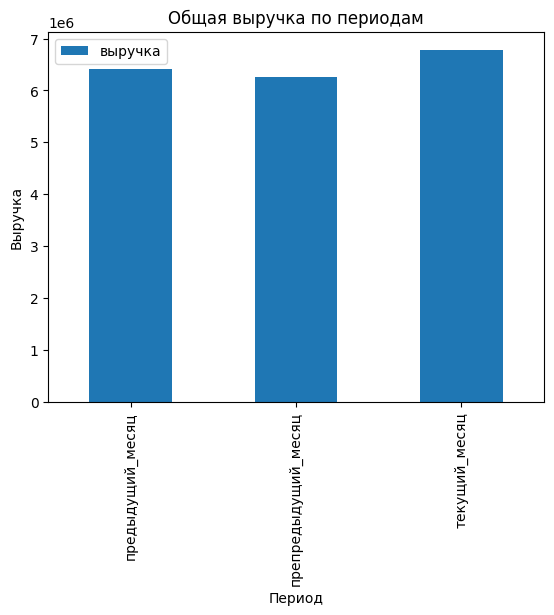

In [51]:
pivot_money = pd.pivot_table(market_money, index='период', values='выручка', aggfunc='sum')
pivot_money.plot(kind='bar')
plt.title('Общая выручка по периодам')
plt.xlabel('Период')
plt.ylabel('Выручка')
plt.show()

Выручка интернет-магазина за последние три месяца немного возрастает каждый месяц. Медиана средних трат клиента в месяц чуть ниже средней, большинство покупок распределены между 4600 и 5360 рублей.

In [52]:
market_time.head()

,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдущий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдущий_месяц,12
4,215350,текущий_месяц,13


In [53]:
market_time['минут'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

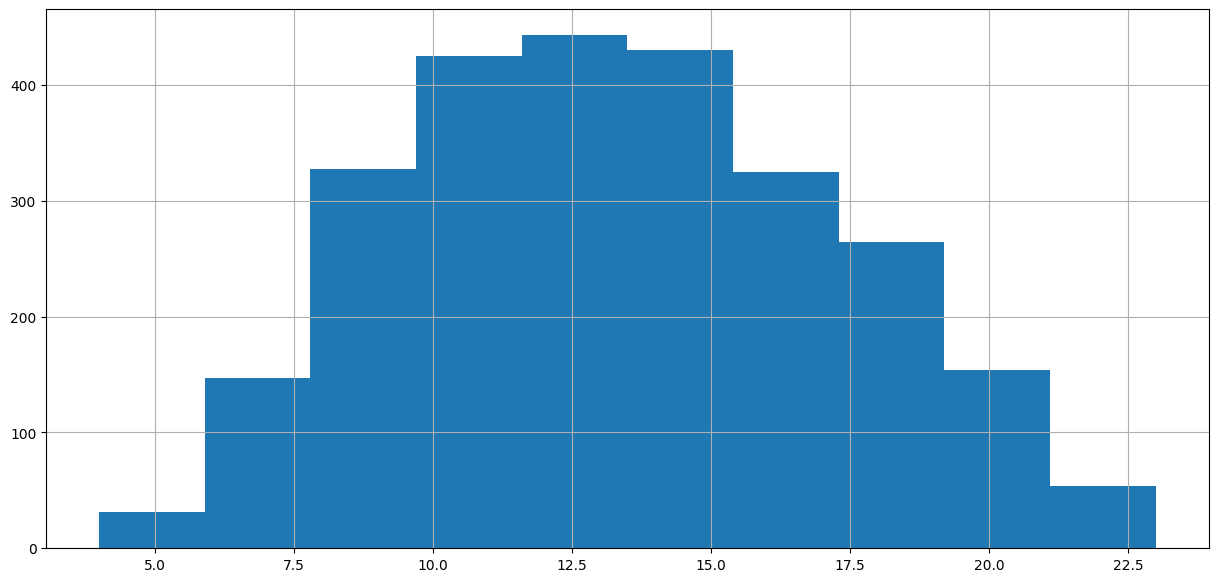

In [54]:
market_time['минут'].hist(figsize = (15, 7), bins=10)
plt.show();

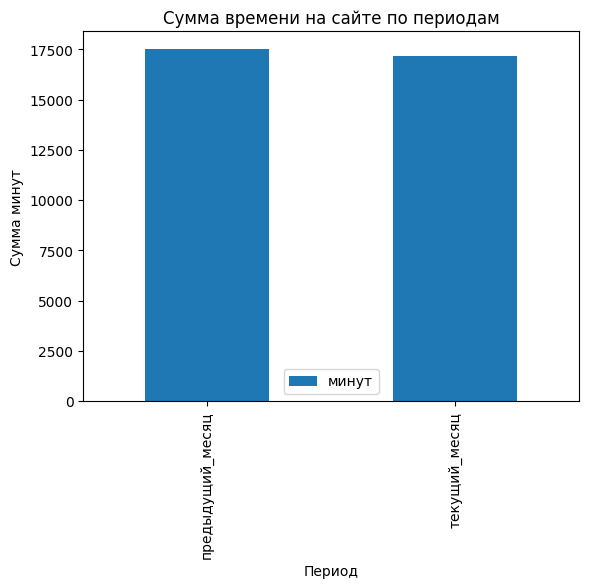

In [55]:
pivot_time = pd.pivot_table(market_time, index='период', values='минут', aggfunc=['sum', 'mean', 'median'])
pivot_time['sum'].plot(kind='bar')
plt.title('Сумма времени на сайте по периодам')
plt.xlabel('Период')
plt.ylabel('Сумма минут')
plt.show()



Среднее время на сайте 13.34 минуты, медиана 13 минут. В среднем на сайте люди проводят от 9.5 до 15.5 минут. Данные по месяцам есть только за два месяца, общее время на сайте в текущем месяце (как и маркетинговая активность) немного сократилось, хотя выручка выросла. Надо будет смотреть по следующему месяцу: это эффект от маркетинга в предыдущем месяце ли маркетинг в текущем месяце стал эффективнее.

In [56]:
money.head()

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [57]:
money['прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

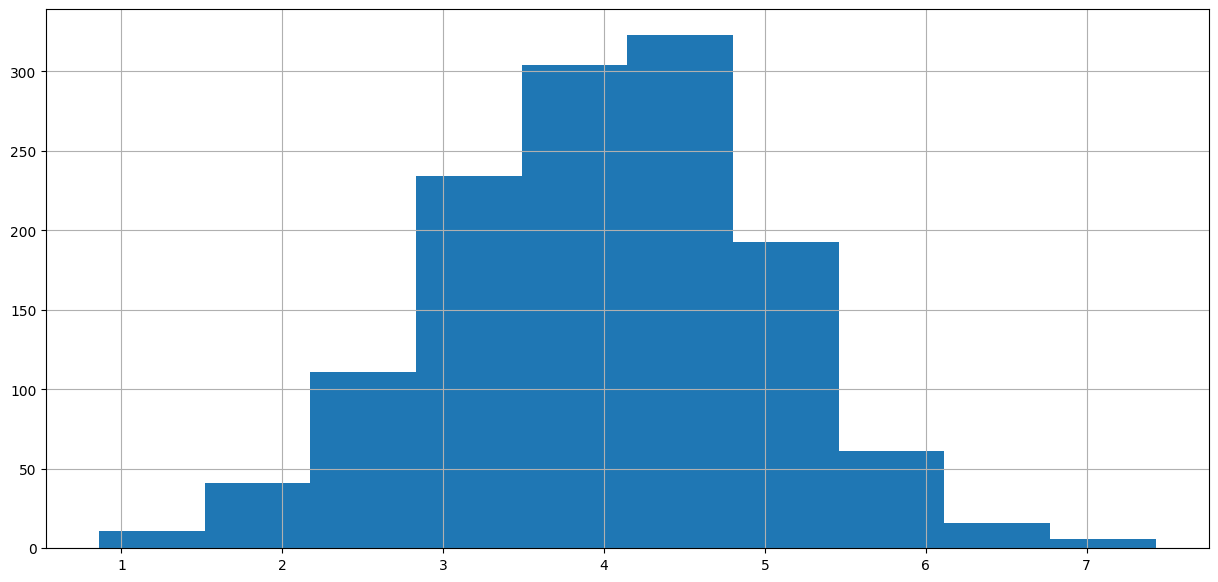

In [58]:
money['прибыль'].hist(figsize = (15, 7), bins=10)
plt.show();

Медианный доход от одного клиента в условных единицах компании чуть выше среднего. Соотношение количество клиентов с доходом от них относительно плавно растет до пика в 4.7 для чуть больше 310 клиентов, потом довольно резко снижается

## Объединение таблиц

Объединим для построение модели данные из таблицы market_file.csv, market_money.csv, market_time.csv в одну итоговую таблицу. Объединять будем по id клиента, при этом надо учесть, что id уникально только для market_file, в остальных таблицах для каждого клиента две или три (в зависимости от таблицы) отдельных строки: за текущий, предыдущий и предпредыдущий месяцы. Мы эти данные сделаем отдельными столбцами в итоговой таблице. 
Прежде удалим из market_file клиентов, которых мы удалили из market_money с нулевыми и с аномольно высокой покупкой, а именно: 215380, 215348, 215357, 215359 

In [59]:
market_file = market_file[~market_file['id'].isin([215380, 215348, 215357, 215359])]

In [60]:
market_time = market_time[~market_time['id'].isin([215380, 215348, 215357, 215359])]

In [61]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 1 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   покупательская_активность            1296 non-null   object 
 2   тип_сервиса                          1296 non-null   object 
 3   разрешить_сообщать                   1296 non-null   object 
 4   маркет_актив_6_мес                   1296 non-null   float64
 5   маркет_актив_тек_мес                 1296 non-null   int64  
 6   длительность                         1296 non-null   int64  
 7   акционные_покупки                    1296 non-null   float64
 8   популярная_категория                 1296 non-null   object 
 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 11  ошибка_сервиса                

In [62]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2592 entries, 2 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2592 non-null   int64 
 1   период  2592 non-null   object
 2   минут   2592 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 81.0+ KB


In [63]:
market_time['период'].value_counts()

текущий_месяц       1296
предыдущий_месяц    1296
Name: период, dtype: int64

In [64]:
market_time_current = market_time[market_time['период'] == 'текущий_месяц'][['id', 'минут']]
market_time_current.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 2 to 2598
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1296 non-null   int64
 1   минут   1296 non-null   int64
dtypes: int64(2)
memory usage: 30.4 KB


In [65]:
market_time_last = market_time[market_time['период'] == 'предыдущий_месяц'][['id', 'минут']]
market_time_last.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 3 to 2599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1296 non-null   int64
 1   минут   1296 non-null   int64
dtypes: int64(2)
memory usage: 30.4 KB


In [66]:
market_file = pd.merge(market_file, market_time_current, on='id', how='left')
market_file = market_file.rename(columns={'минут': 'время_текущий_месяц'})

In [67]:
market_file = pd.merge(market_file, market_time_last, on='id', how='left')
market_file = market_file.rename(columns={'минут': 'время_предыдущий_месяц'})

In [68]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3888 entries, 3 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3888 non-null   int64  
 1   период   3888 non-null   object 
 2   выручка  3888 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 121.5+ KB


In [69]:
market_money['период'].value_counts()

препредыдущий_месяц    1296
текущий_месяц          1296
предыдущий_месяц       1296
Name: период, dtype: int64

In [70]:
market_money_current = market_money[market_money['период'] == 'текущий_месяц'][['id', 'выручка']]
market_money_current.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 4 to 3899
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1296 non-null   int64  
 1   выручка  1296 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 30.4 KB


In [71]:
market_money_last = market_money[market_money['период'] == 'предыдущий_месяц'][['id', 'выручка']]
market_money_last.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 5 to 3897
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1296 non-null   int64  
 1   выручка  1296 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 30.4 KB


In [72]:
market_money_last_last = market_money[market_money['период'] == 'препредыдущий_месяц'][['id', 'выручка']]
market_money_last_last.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 3 to 3898
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1296 non-null   int64  
 1   выручка  1296 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 30.4 KB


In [73]:
market_file = pd.merge(market_file, market_money_current, on='id', how='left')
market_file = market_file.rename(columns={'выручка': 'деньги_текущий_месяц'})

In [74]:
market_file = pd.merge(market_file, market_money_last, on='id', how='left')
market_file = market_file.rename(columns={'выручка': 'деньги_предыдущий_месяц'})

In [75]:
market_file = pd.merge(market_file, market_money_last_last, on='id', how='left')
market_file = market_file.rename(columns={'выручка': 'деньги_препредыдущий_месяц'})

In [76]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   покупательская_активность            1296 non-null   object 
 2   тип_сервиса                          1296 non-null   object 
 3   разрешить_сообщать                   1296 non-null   object 
 4   маркет_актив_6_мес                   1296 non-null   float64
 5   маркет_актив_тек_мес                 1296 non-null   int64  
 6   длительность                         1296 non-null   int64  
 7   акционные_покупки                    1296 non-null   float64
 8   популярная_категория                 1296 non-null   object 
 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 11  ошибка_сервиса                

## Корреляционный анализ

Проведем корреляционный анализ признаков в количественной шкале в объединенной таблице. Для этого подготовим отдельную таблицу без категориальных данных и сделаем список с непрерывными признаками

In [77]:
market_file_corr = market_file.drop(
    ['id', 'покупательская_активность', 'тип_сервиса', 'популярная_категория', 'разрешить_сообщать'], 
    axis=1
)

In [78]:
interval_cols = [
    'маркет_актив_6_мес', 
    'маркет_актив_тек_мес', 
    'длительность',
    'акционные_покупки',
    'время_текущий_месяц',
    'время_предыдущий_месяц',
    'деньги_текущий_месяц',
    'деньги_предыдущий_месяц',
    'деньги_препредыдущий_месяц'
]

In [79]:
phik_overview = phik_matrix(market_file_corr, interval_cols=interval_cols) 

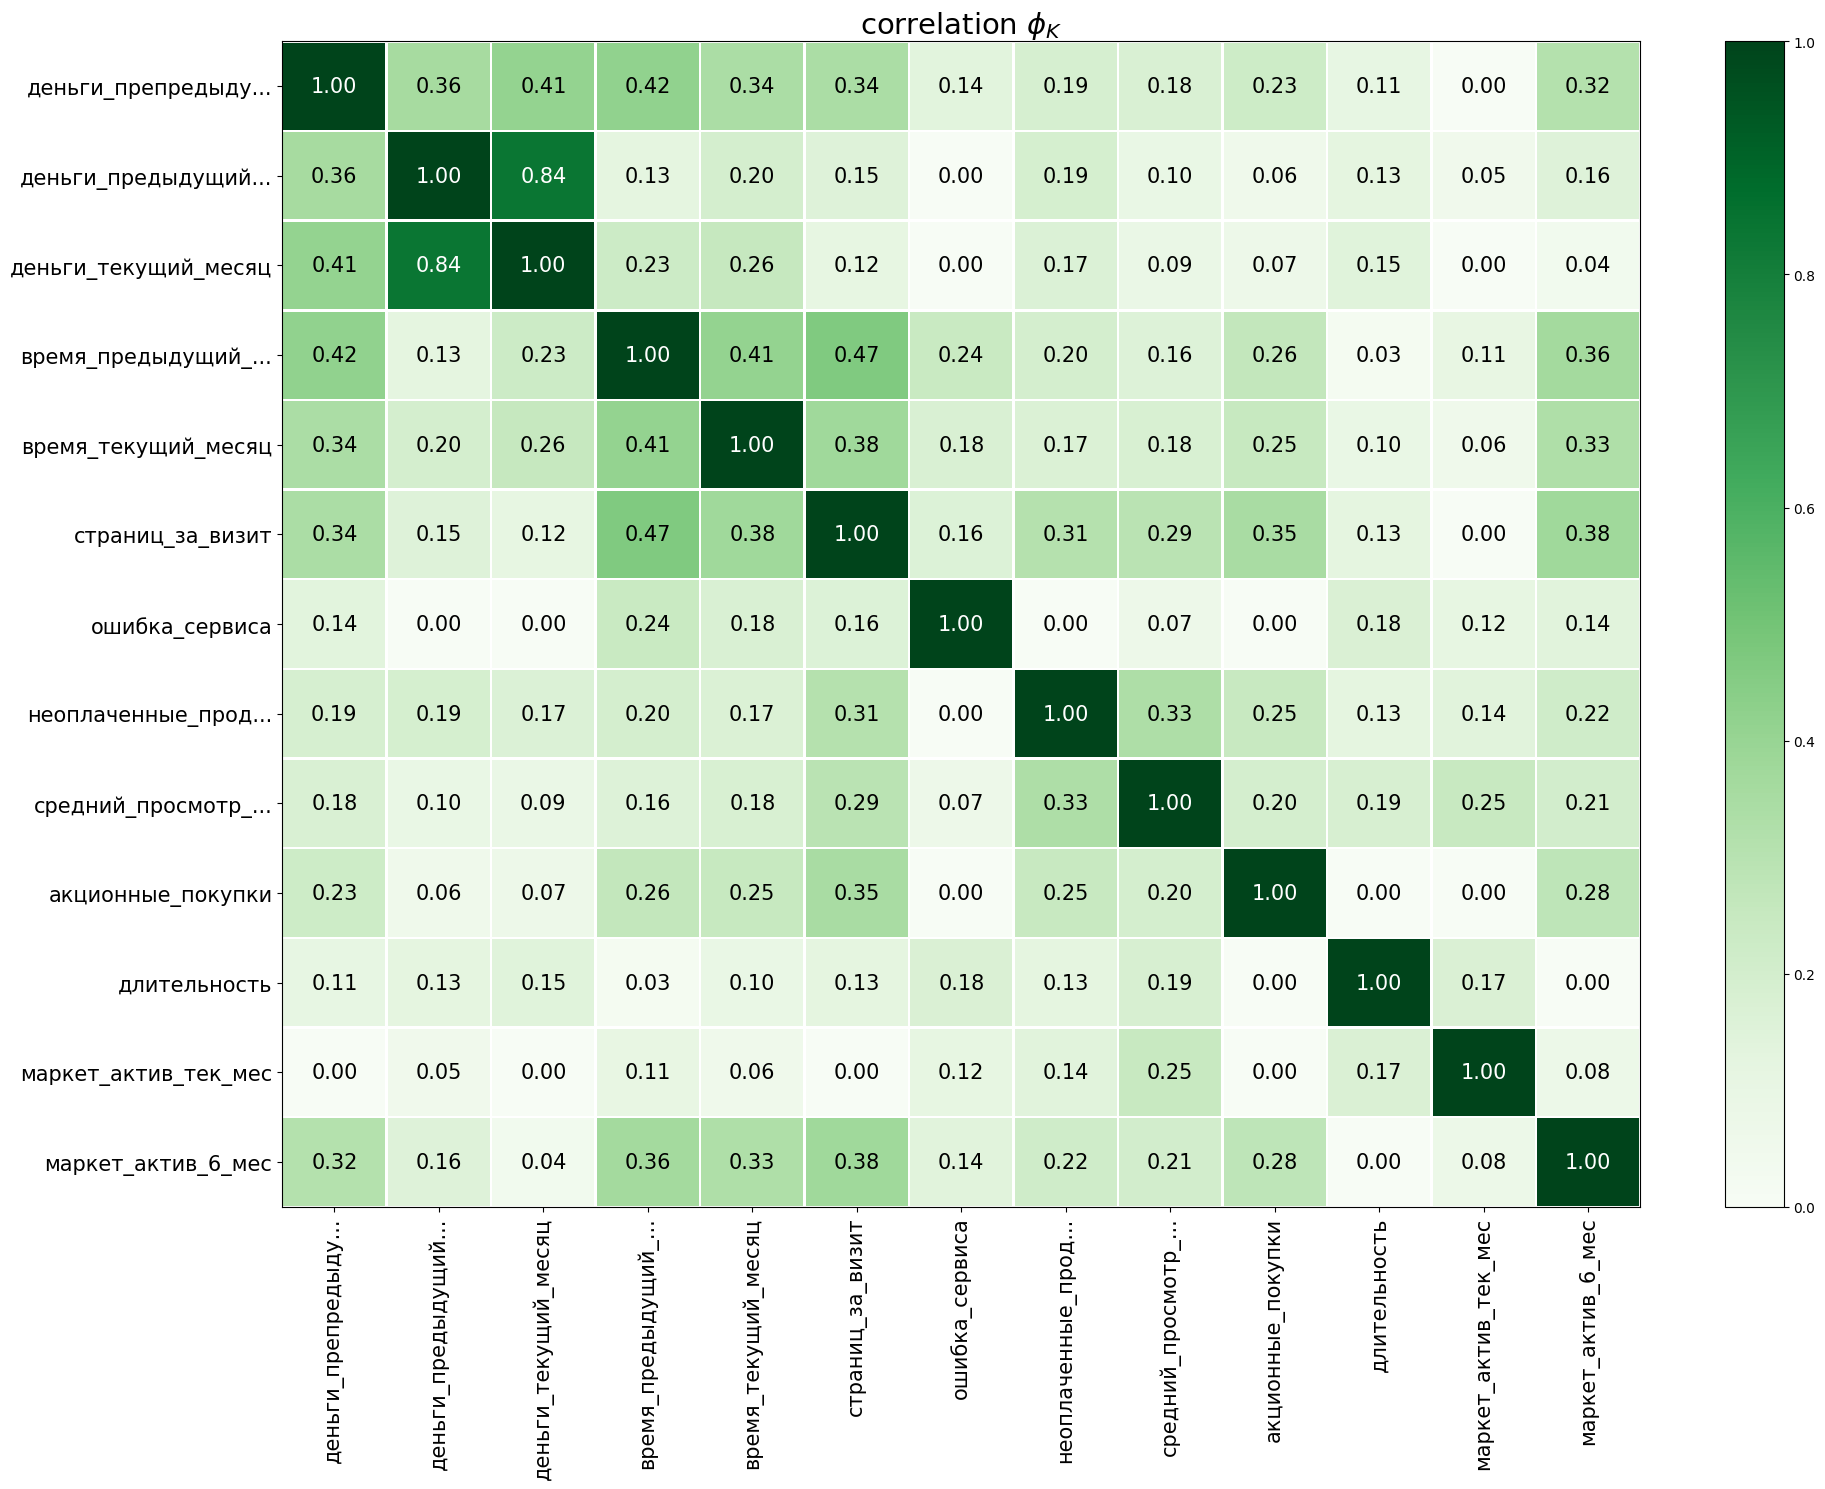

In [80]:
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Большой корреляции между количественными признаками нет. Разве что можно говорить о корреляции данных о потраченных денежных средствах за текущий и за предыдущий месяц, что логично. Но при этом странно, что нет большой корреляции с данными за предпредыдущий месяц. Посмотрим матрицу корреляции с некодированными категориальными признаками.

In [81]:
market_file_corr_1 = market_file.drop(['id'], axis=1)

In [82]:
phik_overview_1 = phik_matrix(market_file_corr_1, interval_cols=interval_cols) 

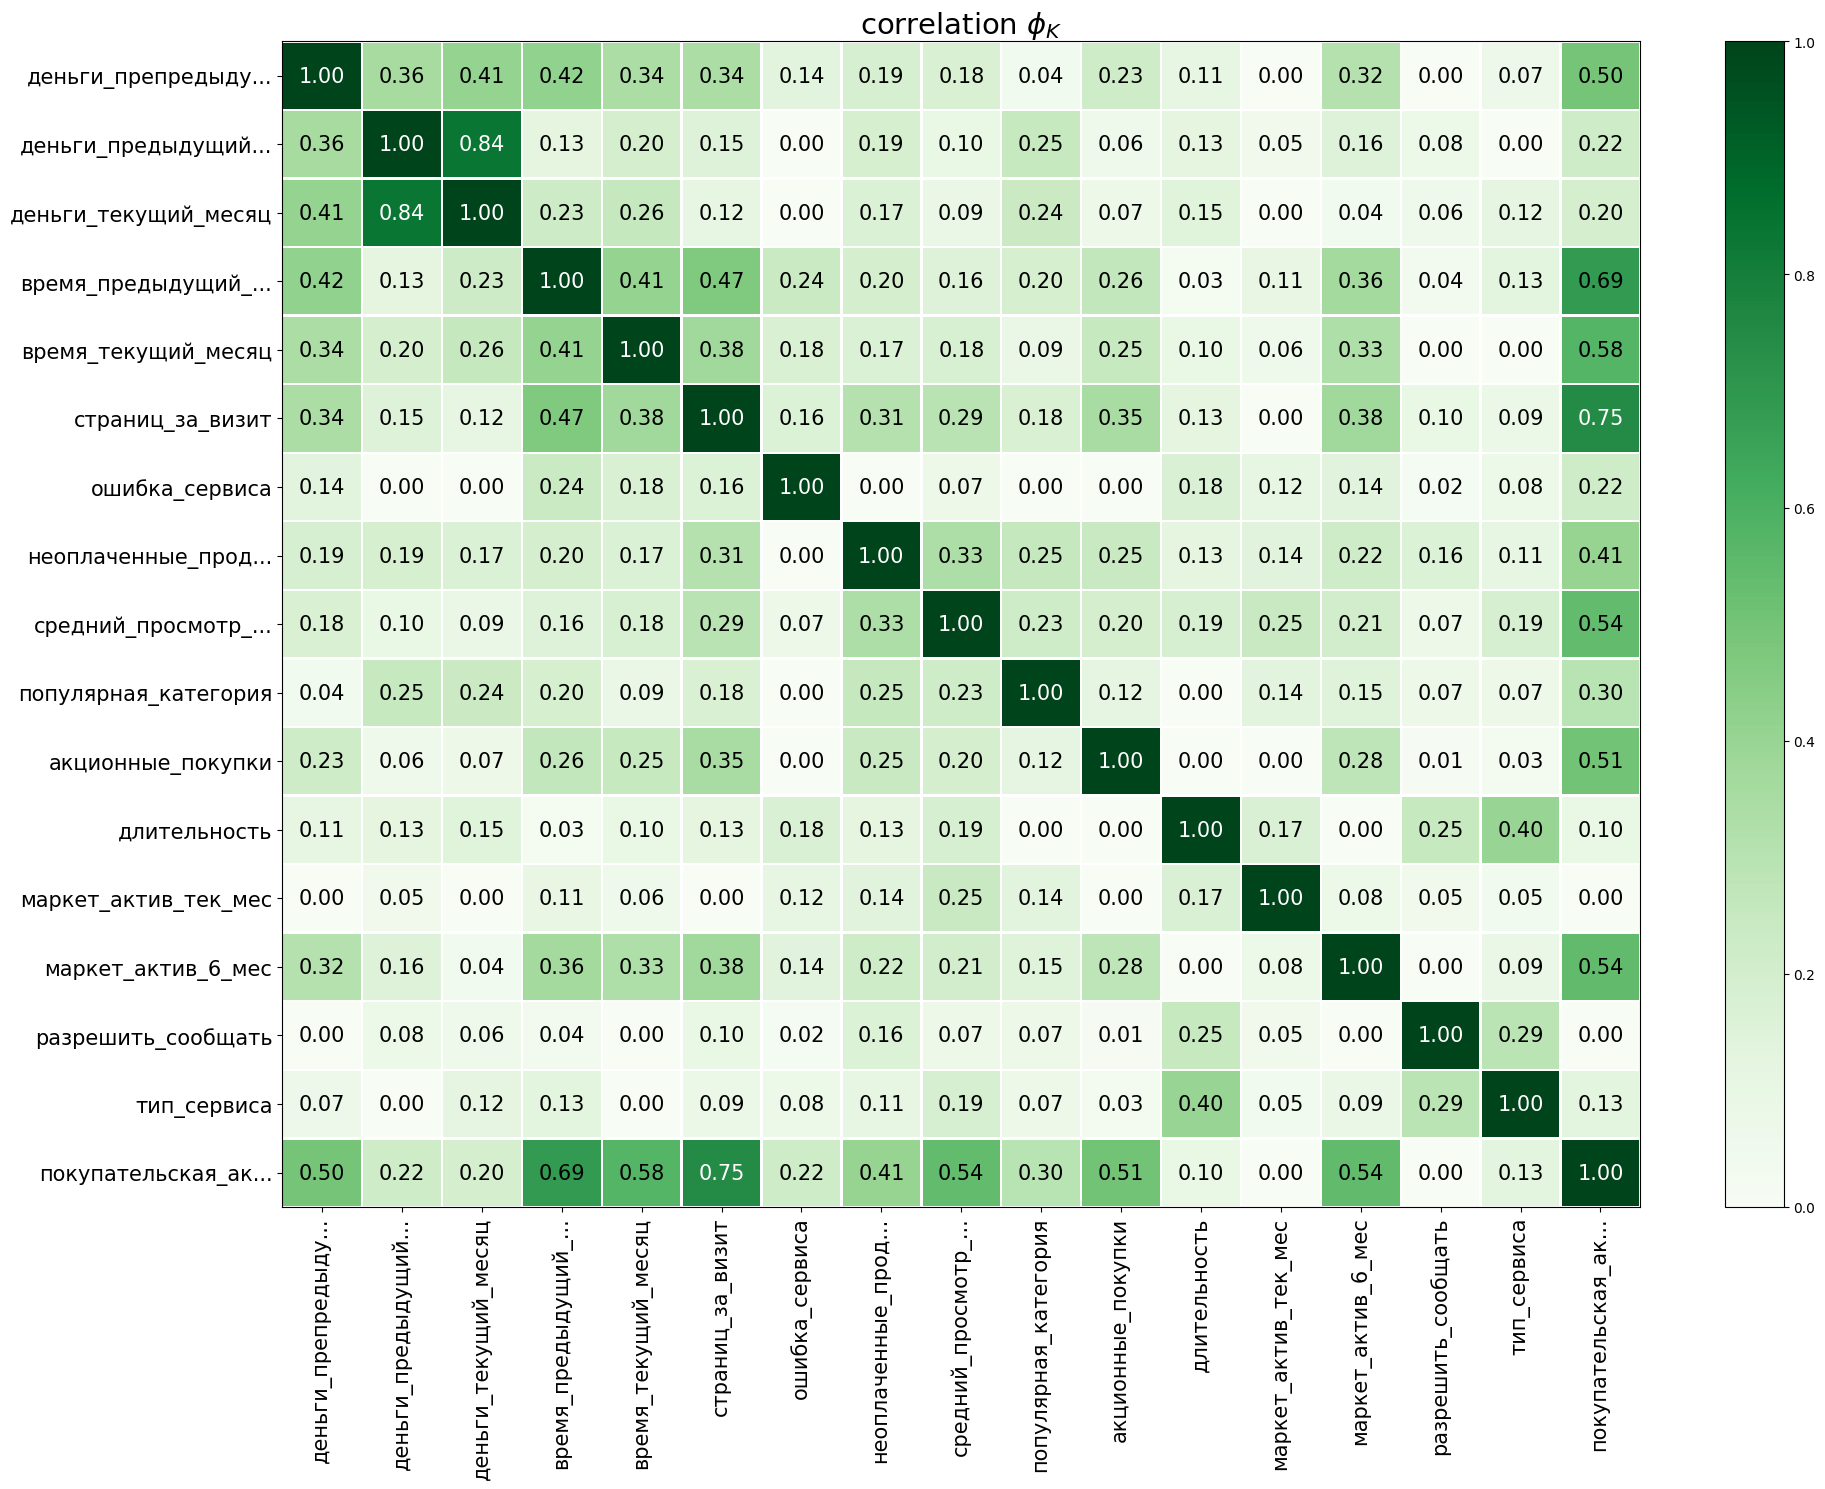

In [83]:
plot_correlation_matrix(
    phik_overview_1.values,
    x_labels=phik_overview_1.columns,
    y_labels=phik_overview_1.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Здесь видим значиму корреляцию целевого признака с просмотренными страницами за визит, временем посещения сайт, средним просмотром категорий за визит. Логически рассуждая, данные признаки и должны быть связаны: чтобы что-то купить, нужно найти товар, просмотреть по нему информацию, посмотреть похожие товары. ЛОгически данные признаки связаны, но корреляция недостаточно большая, чтобы думать об удалении части данных признаков. Также целевой признак покупательской способности значимо коррелирует с маркетинговой активностью за 6 месяцев (при этом нет корреляции с текущим месяцем), акционными покупками. Также есть значимая корреляция с потраченными денежными средствами за предпредыдущий месяц (но не за последующие).

Посмотрим на статистику характеристик покупателей снижающих покупательскую активностьи и сохраняющих на прежнем уровне, а также определим распределение признаков в разрезе целевого признака, чтобы составить представление как влиет снижение/неснижение покупательской активности на имеющиеся данные о покупателях и интернет-магазине.

In [84]:
market_file['маркет_актив_6_мес'].describe()

count    1296.000000
mean        4.256404
std         1.013525
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64

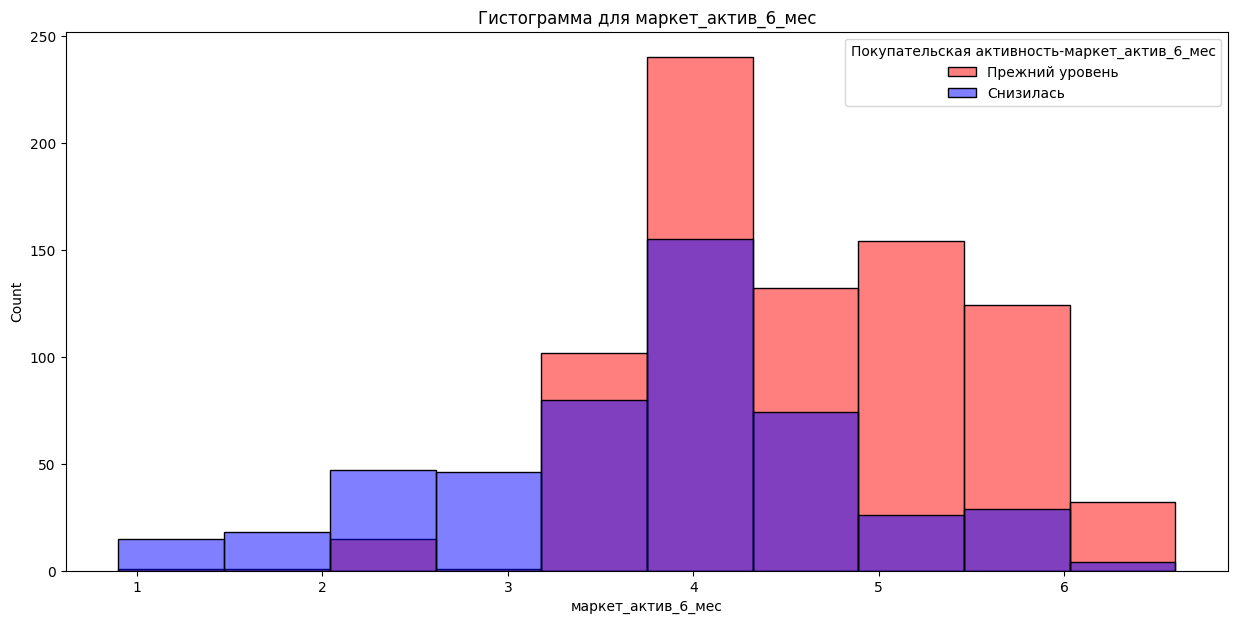

In [85]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='маркет_актив_6_мес', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-маркет_актив_6_мес', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для маркет_актив_6_мес')
plt.show()

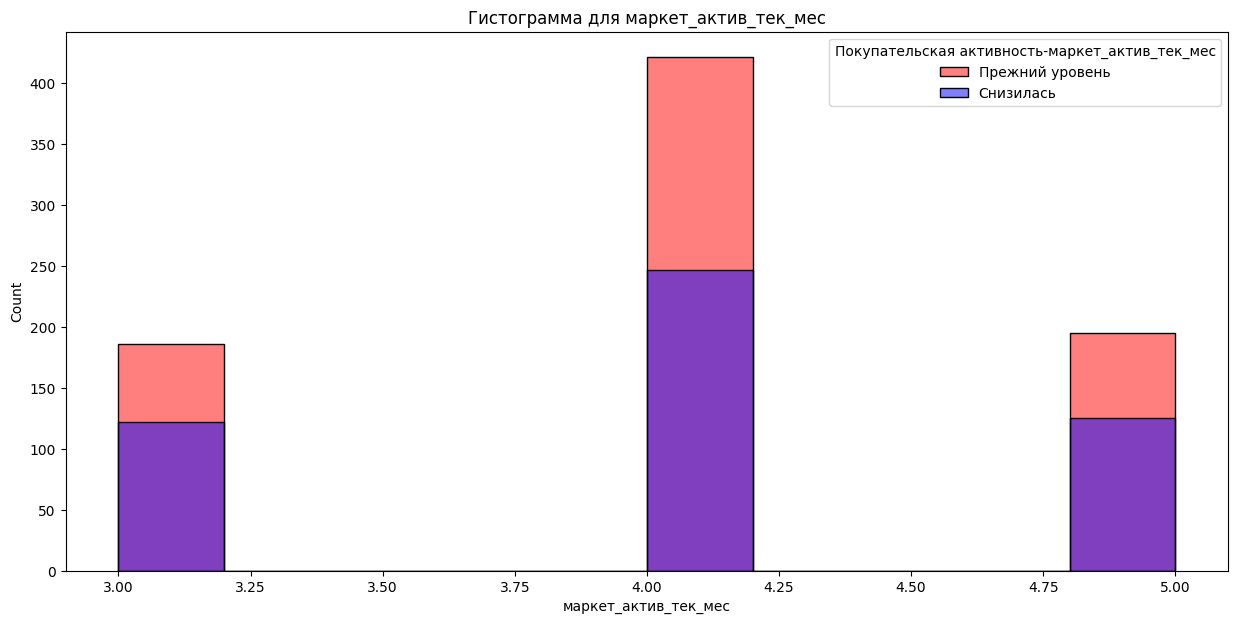

In [86]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='маркет_актив_тек_мес', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-маркет_актив_тек_мес', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для маркет_актив_тек_мес')
plt.show()

За прошедшие 6 месяцев признак снижение покупательской активности начинал падать при маркетинговой активности магазина выше 4 акций в месяц, при маркетинговой активности магазина 5 и более акций в месяц покупателей, снизивших покупательскую активность, уже в разы меньше, чем сохранивших покупательскую активность. По данным за 6 месяцев можно было бы сделать вывод, что магазину нужно проводить не менее 5 акций в месяц, но данные за текущий месяц это не подтверждают. Соотношение покупателей, сохранивших покупательскую активность к снизившим, примерно одинаково на 3, 4 и 5 акциях. Либо эффект от маркетинговых акций в текущем месяце еще не наступил, либо надо смотреть как изменились маркетинговые акции в последний месяц.

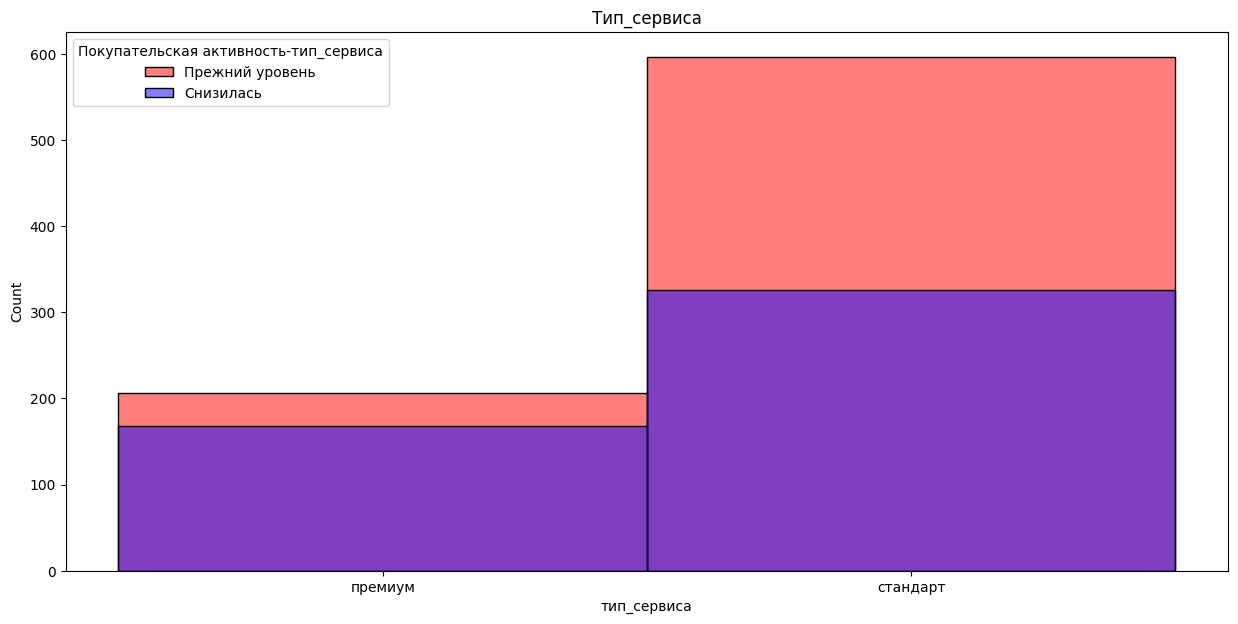

In [87]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='тип_сервиса', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-тип_сервиса', labels=['Прежний уровень', 'Снизилась'])
plt.title('Тип_сервиса')
plt.show()

Наличие премиума не влияет на потребительскую активность (доля покупателей, снижающих/неснижающих потребительскую активность, примерно равно, более того при стандартном типе сервиса больше людей, не снижающих потребительскую активность

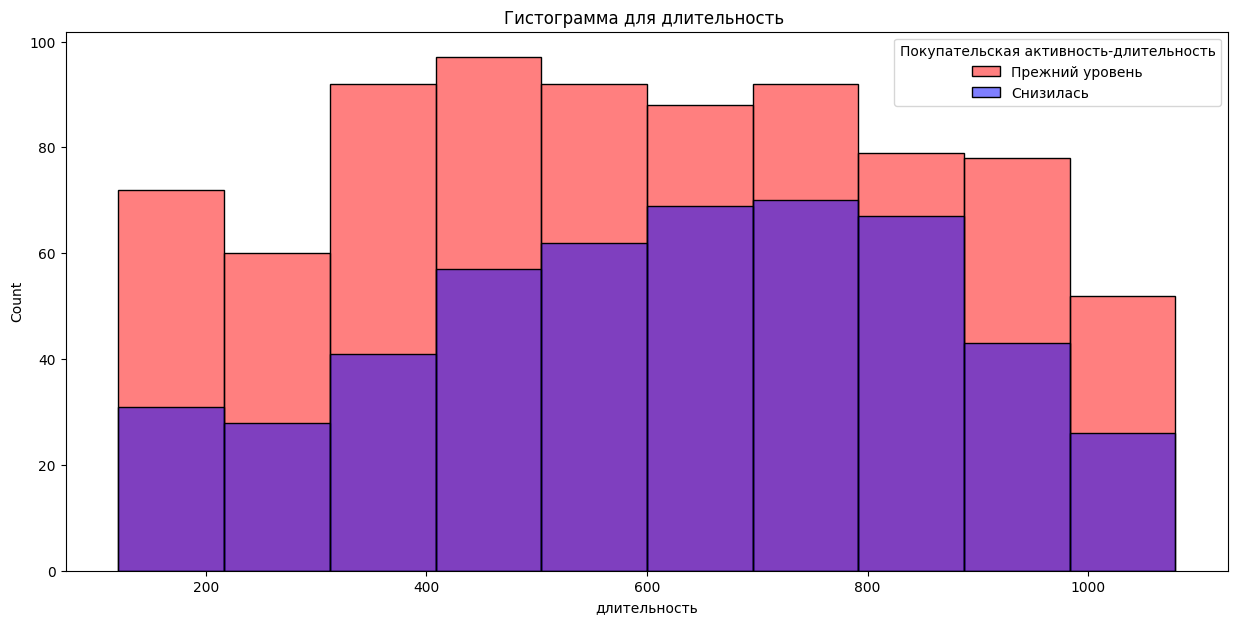

In [88]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='длительность', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-длительность', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для длительность ')
plt.show()

В зависимости от длительности регистрации клиентов более "старые" клиенты и самые новые больше склонны сохранять покупательску активность

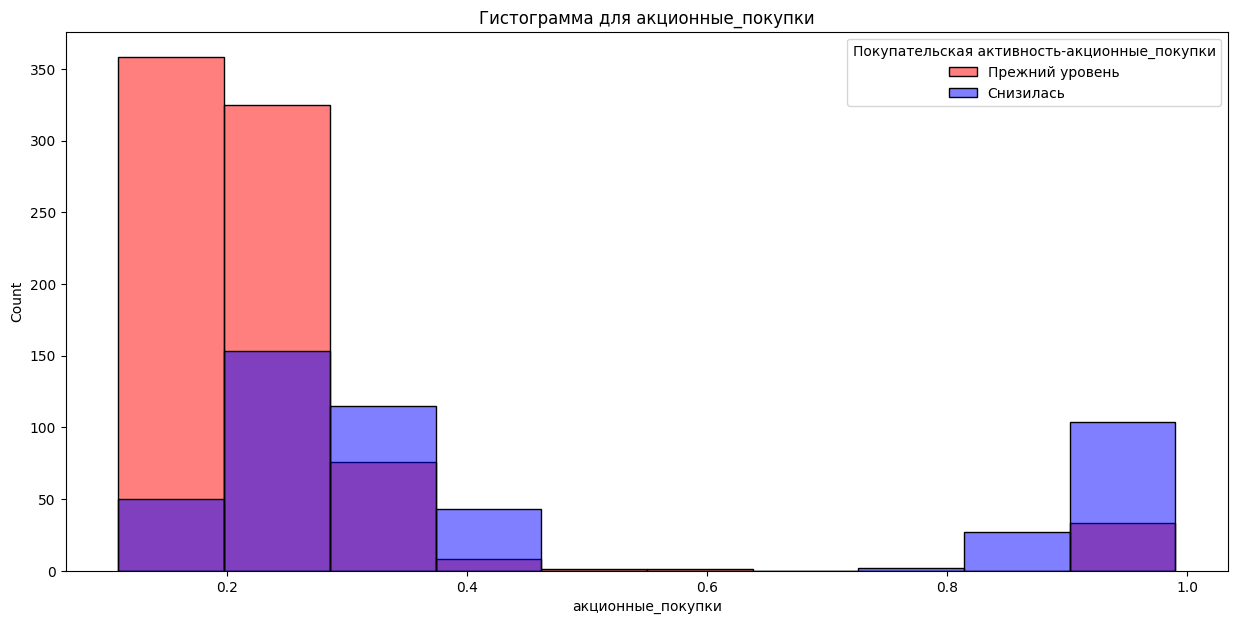

In [89]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='акционные_покупки', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-акционные_покупки', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для акционные_покупки')
plt.show()

Клиенты с большим количеством акционных покупок демонстрируют снижение покупательской активности.

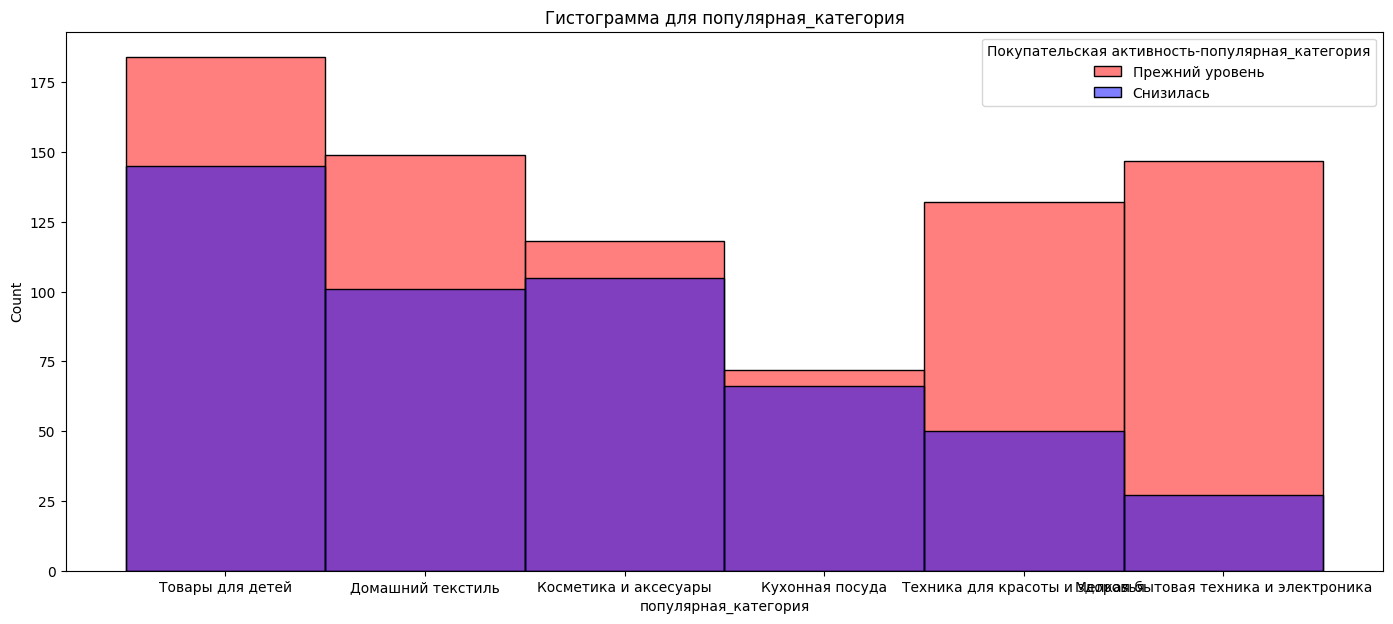

In [90]:
plt.figure(figsize=(17, 7))
sns.histplot(data=market_file, x='популярная_категория', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-популярная_категория', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для популярная_категория')
plt.show()

Клиенты с любимыми категориями Бытовая техника и электроника, а также техника для красоты и здоровья более склонны сохранять покупательскую активность. Необходимо посмотреть, чем отличаются маркетинговые акции в разрезе разных категорий техники. Также нужно посмотреть, чем отличается представление на сайте данных товаров (как данные категории товаров представлены в других интернет-магазинах). Возможно стоит по остальным категориям товаров уточнить описание, удобство просмотров, рекомендаций

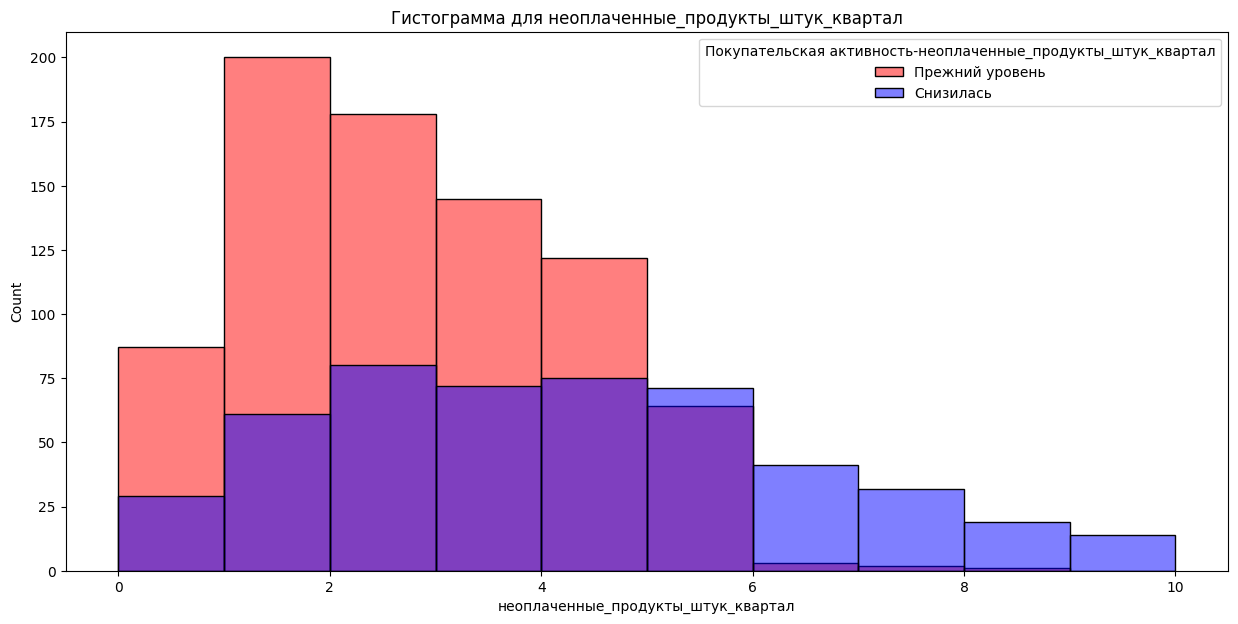

In [91]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='неоплаченные_продукты_штук_квартал', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-неоплаченные_продукты_штук_квартал', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для неоплаченные_продукты_штук_квартал')
plt.show()

Как уже отмечалось, снижение покупательской активности характерно для лиц, имеющих много неоплаченных продуктов в корзине. Свыше двух продуктов начинается снижаться количество покупателей, сохраняющих покупательскую активность. Маркетинговому отделу необходимо обращать внимание на покупателей, накапливаюих более двух неоплаченных товаров. 

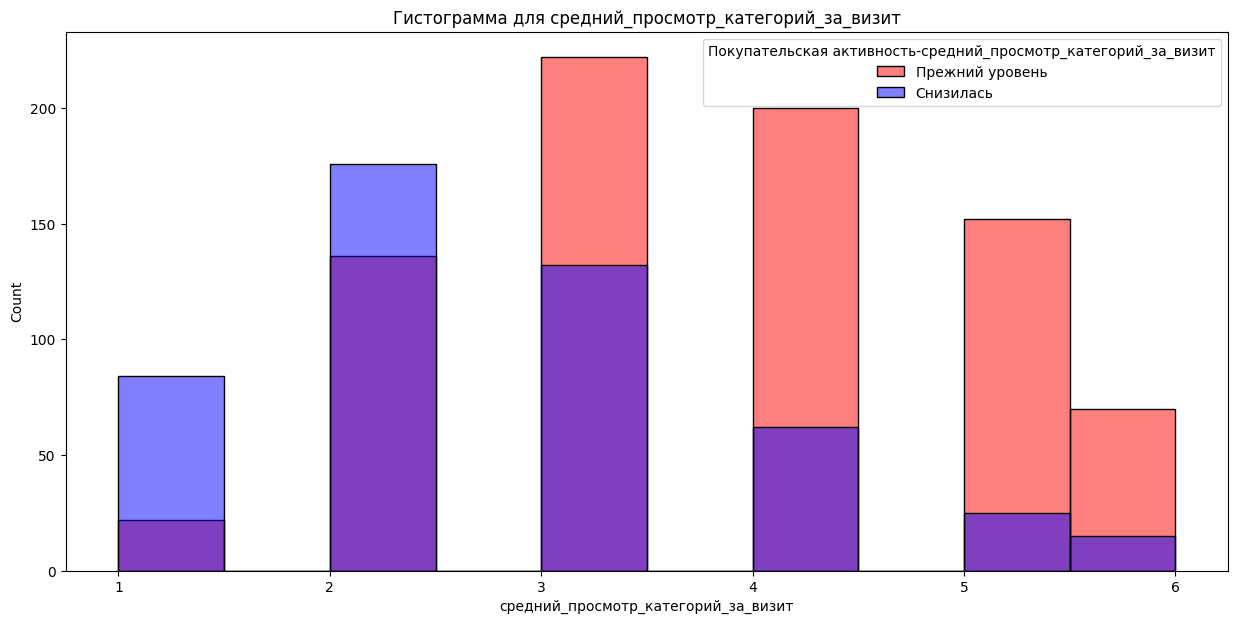

In [92]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='средний_просмотр_категорий_за_визит', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-средний_просмотр_категорий_за_визит', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для средний_просмотр_категорий_за_визит')
plt.show()

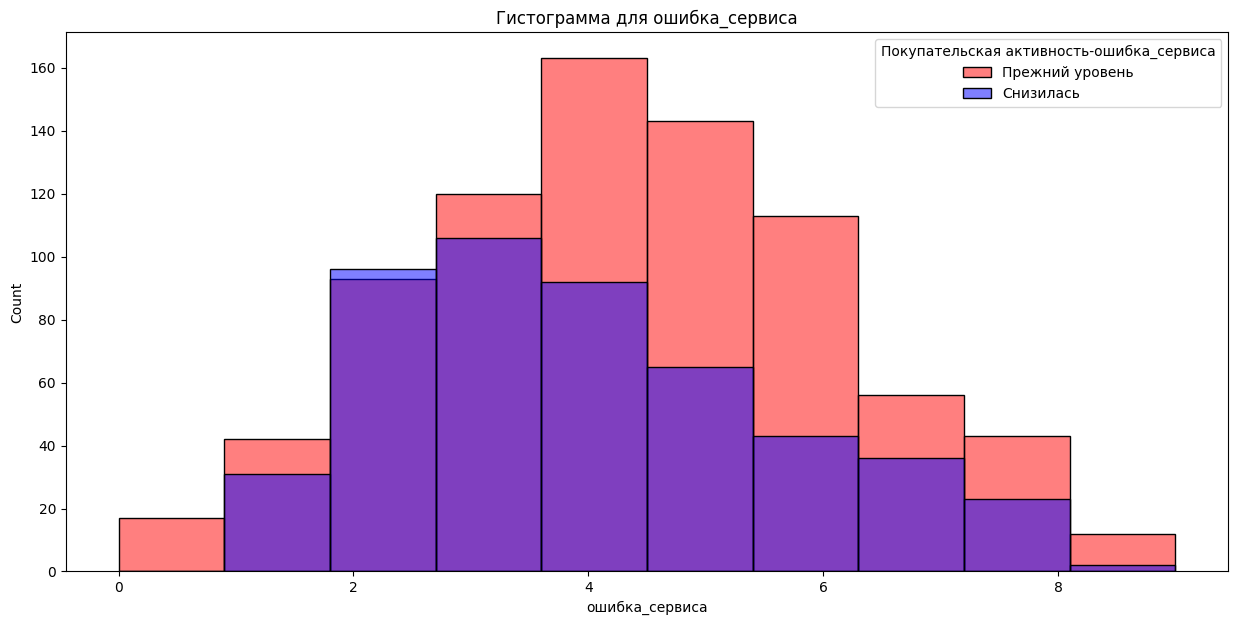

In [93]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='ошибка_сервиса', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-ошибка_сервиса', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для ошибка_сервиса')
plt.show()

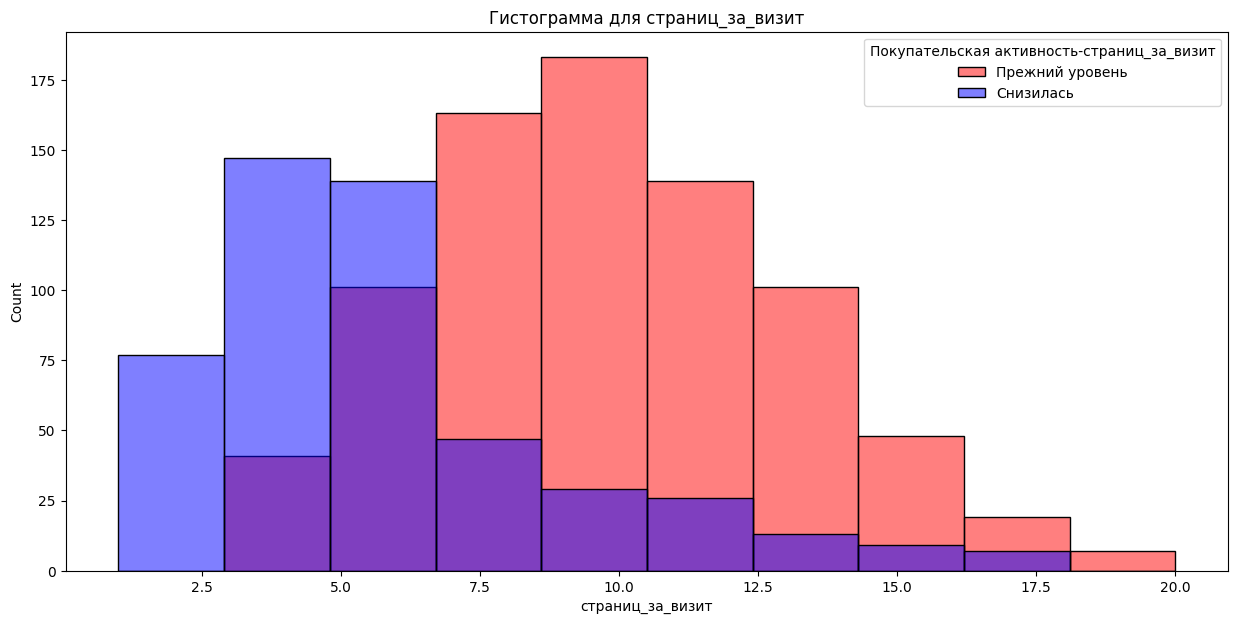

In [94]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='страниц_за_визит', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-страниц_за_визит', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для страниц_за_визит')
plt.show()

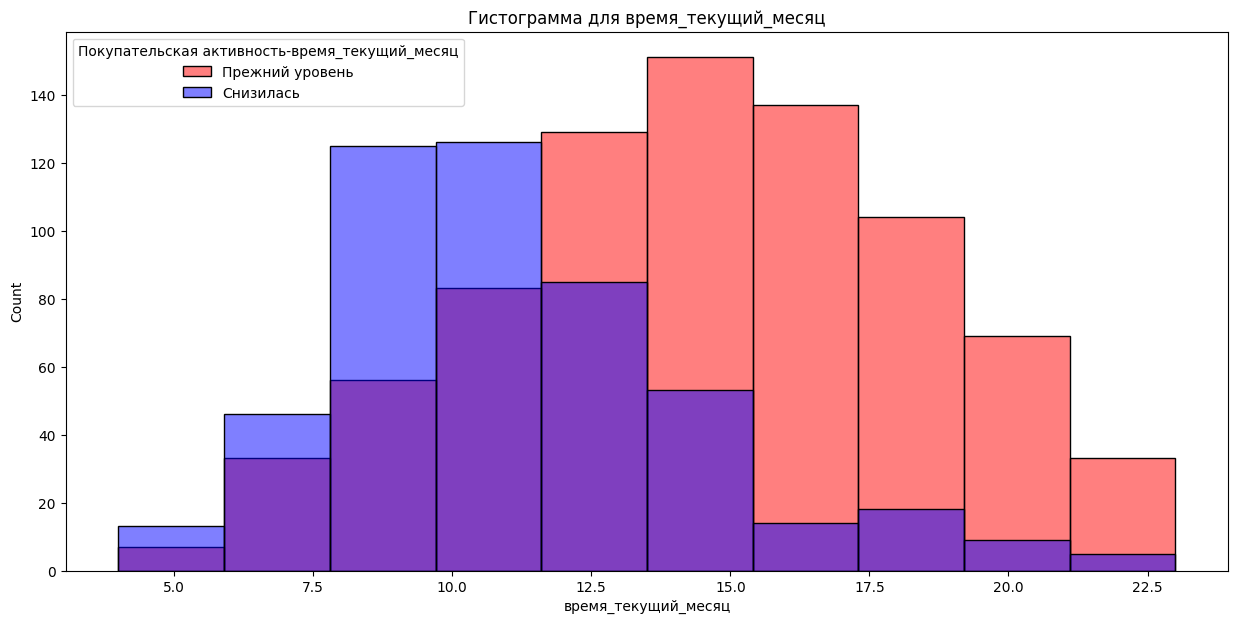

In [95]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='время_текущий_месяц', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-время_текущий_месяц', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для время_текущий_месяц')
plt.show()

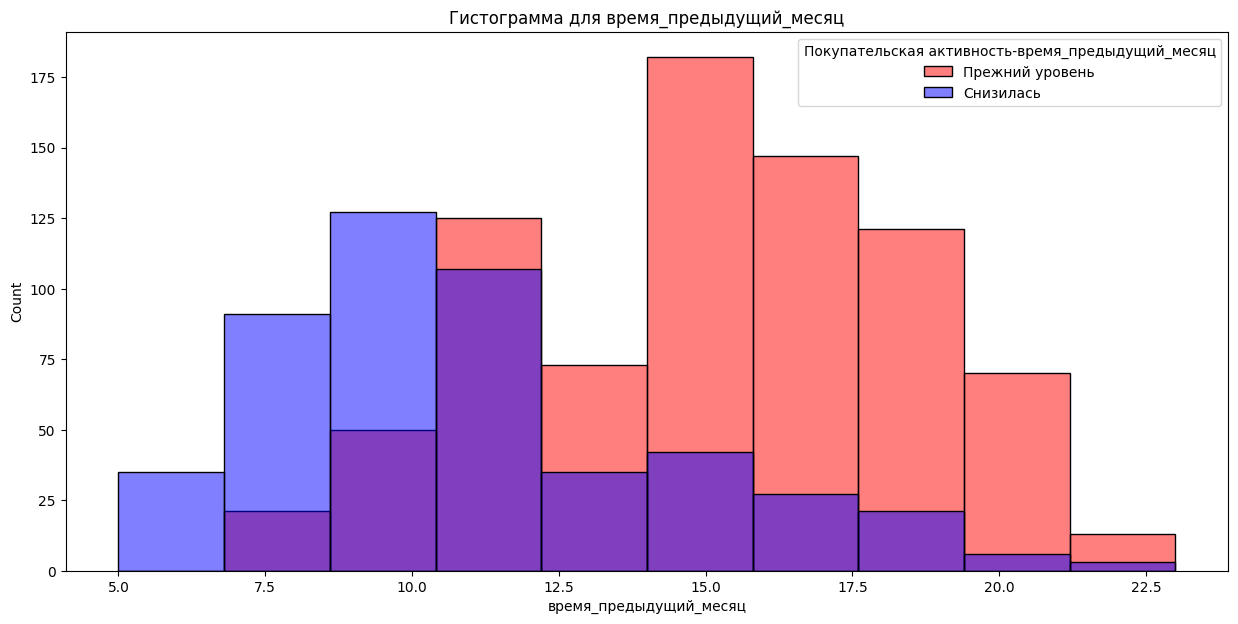

In [96]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='время_предыдущий_месяц', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-время_предыдущий_месяц', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для время_предыдущий_месяц')
plt.show()

Для покупателей, сохраняющих покупательскую активность, характерно просматривать больше страниц, категорий товаров. При просмотре начиная с 7.5 страниц и 3 категорий товаров, резко падает количество клиентов, снижающих покупательскую активность. Возможно, снижение покупательской активности связано с недоинформированностью клиентов о товарах. При сравнении времени, проведенном на сайте, видно что лица, снижающие покупательскую активность, в текущем месяце стали чуть больше времени проводить на сайте, чем в предыдущем. 

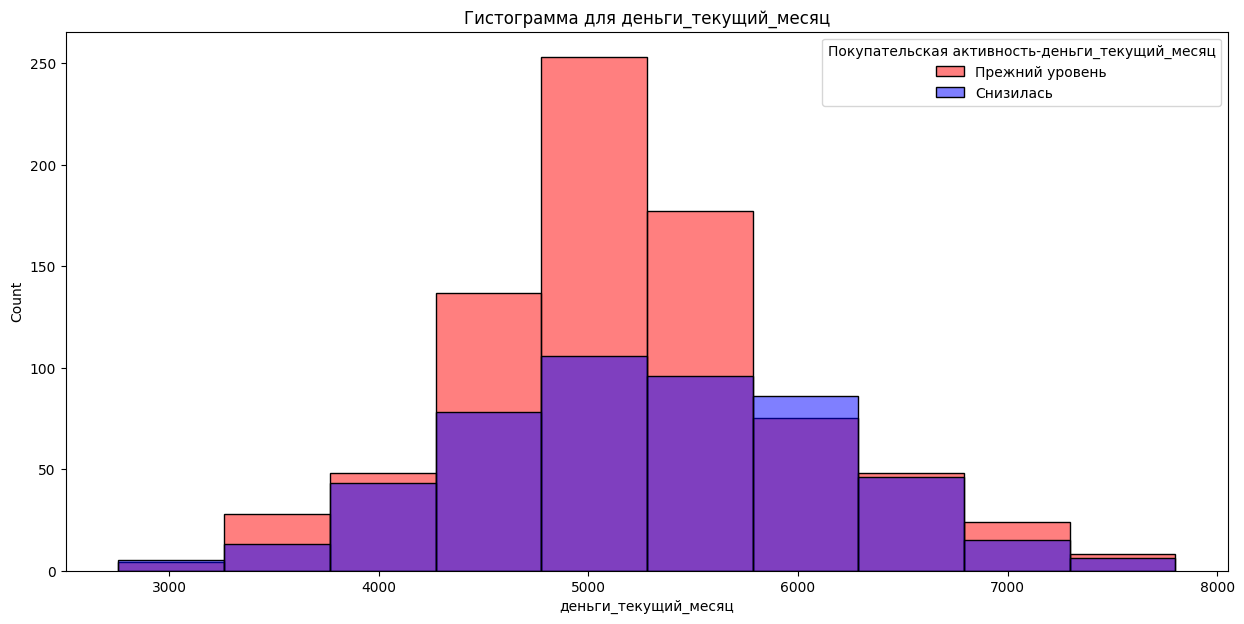

In [97]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='деньги_текущий_месяц', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-деньги_текущий_месяц', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для деньги_текущий_месяц')
plt.show()

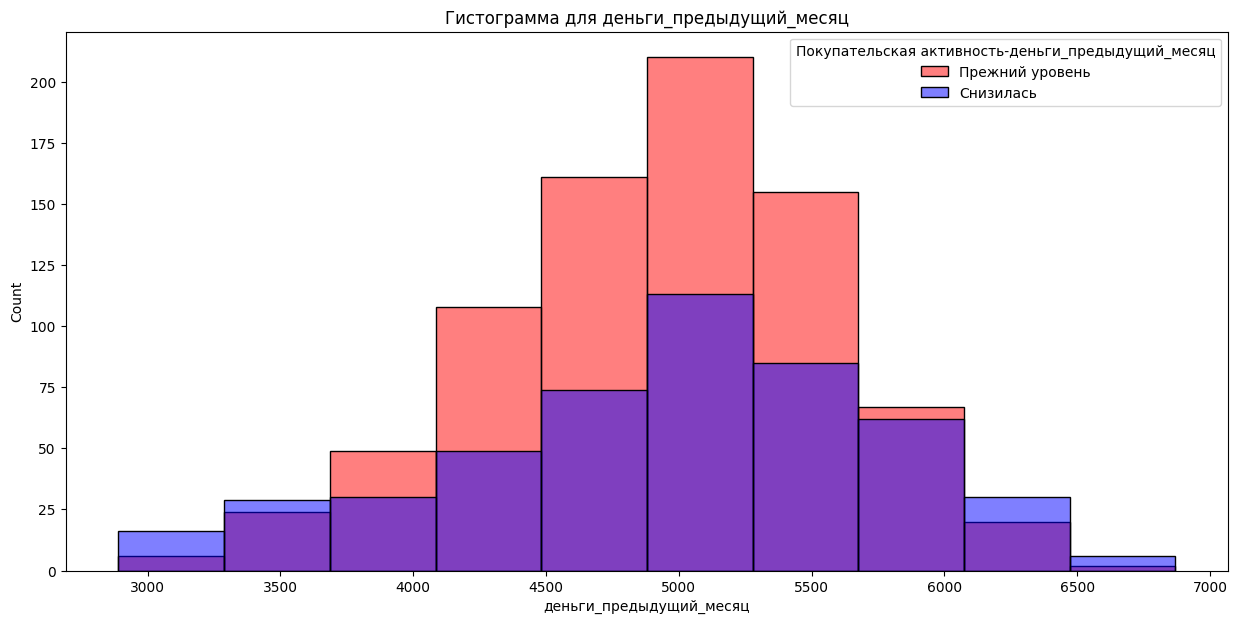

In [98]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='деньги_предыдущий_месяц', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-деньги_предыдущий_месяц', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для деньги_предыдущий_месяц')
plt.show()

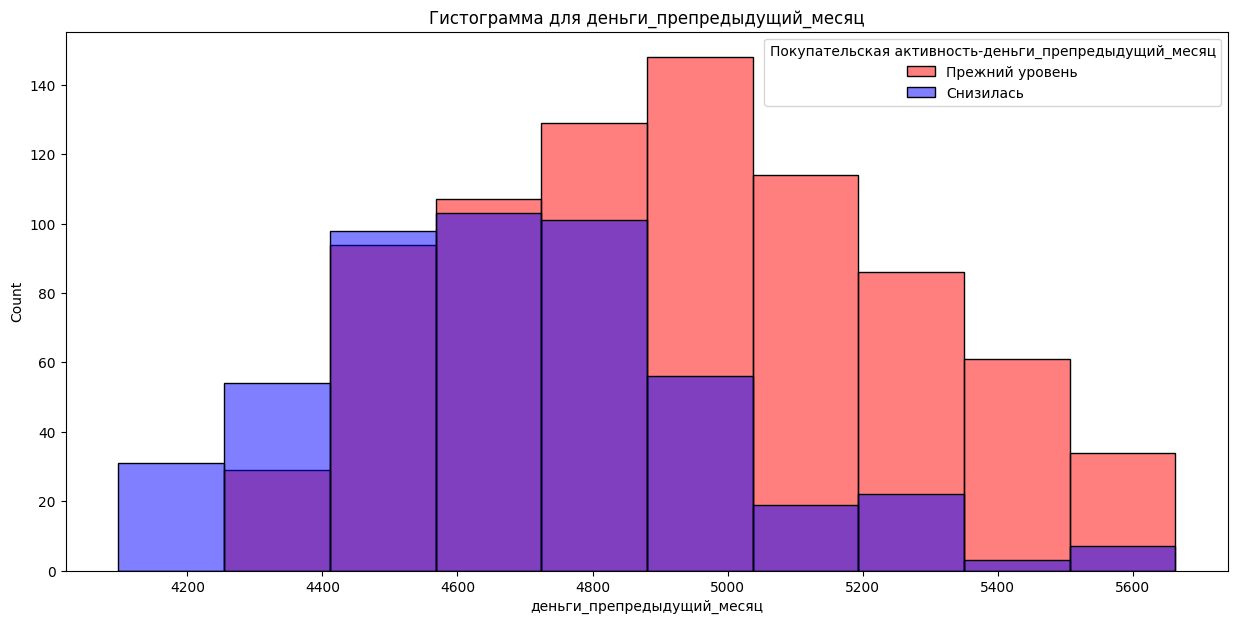

In [99]:
plt.figure(figsize=(15, 7))
sns.histplot(data=market_file, x='деньги_препредыдущий_месяц', hue='покупательская_активность', palette=['blue', 'red'], alpha=0.5, bins=10)
plt.legend(title='Покупательская активность-деньги_препредыдущий_месяц', labels=['Прежний уровень', 'Снизилась'])
plt.title('Гистограмма для деньги_препредыдущий_месяц')
plt.show()

При анализе трат клиентов за три месяца обращает на себя внимание как изменения в отношении клиентов, сохраняющих активность  (максимальное количество таких клиентов группируется вокруг покупок на 5000 рублей, но со временем становится шире разброс сумм покупок и увеличивается количество клиентов со средним количеством покупок), так и клиентов, снизивших покупательскую активность (со временем среднее количество покупок увеличивается, но пик вокруг среднего количества покупок становится более плавным).

In [100]:
market_file[market_file['покупательская_активность'] == 'Снизилась'].describe().T

,count,mean,std,min,25%,50%,75%,max
id,494.0,215612.593117,164.974405,215349.00,215475.250,215598.50,215721.75,215941.00
маркет_актив_6_мес,494.0,3.747166,1.052777,0.90,3.100,3.90,4.40,6.60
маркет_актив_тек_мес,494.0,4.006073,0.707797,3.00,4.000,4.00,5.00,5.00
длительность,494.0,622.834008,237.817052,121.00,449.000,636.50,812.50,1079.00
акционные_покупки,494.0,0.452713,0.304428,0.11,0.240,0.31,0.89,0.99
средний_просмотр_категорий_за_визит,494.0,2.621457,1.223678,1.00,2.000,2.00,3.00,6.00
неоплаченные_продукты_штук_квартал,494.0,3.732794,2.292385,0.00,2.000,4.00,5.00,10.00
ошибка_сервиса,494.0,3.939271,1.882005,1.00,2.000,4.00,5.00,9.00
страниц_за_визит,494.0,5.574899,3.463729,1.00,3.000,5.00,7.00,18.00
время_текущий_месяц,494.0,10.947368,3.418311,4.00,9.000,10.00,13.00,22.00


In [101]:
market_file[market_file['покупательская_активность'] == 'Прежний уровень'].describe().T

,count,mean,std,min,25%,50%,75%,max
id,802.0,216237.761845,246.221370,215748.00,216046.250,216246.50,216446.750,216647.00
маркет_актив_6_мес,802.0,4.570075,0.848618,0.90,4.000,4.40,5.275,6.60
маркет_актив_тек_мес,802.0,4.011222,0.689586,3.00,4.000,4.00,4.000,5.00
длительность,802.0,590.730673,255.330179,121.00,382.500,590.00,798.750,1061.00
акционные_покупки,802.0,0.238367,0.160599,0.11,0.150,0.21,0.260,0.99
средний_просмотр_категорий_за_визит,802.0,3.665835,1.277112,1.00,3.000,4.00,5.000,6.00
неоплаченные_продукты_штук_квартал,802.0,2.293017,1.508255,0.00,1.000,2.00,3.000,8.00
ошибка_сервиса,802.0,4.335411,1.979538,0.00,3.000,4.00,6.000,9.00
страниц_за_визит,802.0,9.796758,3.376846,3.00,7.000,10.00,12.000,20.00
время_текущий_месяц,802.0,14.604738,4.064355,4.00,12.000,15.00,18.000,23.00


Лица, снижающие покупательскую активность:  
- в отношении них меньше проводилось маркетинговой активности за 6 месяцев, выровнялось только в текущем месяце  
- в полтора раза чаще осуществляют акционные покупки и два раза больше неоплаченных товаров в корзине, чем люди сохраняющие покупательскую активность  
- в два раза меньше просматривают страницы и категории товаров за визит, в 1.5 раз меньше проводят времени на сайте  
- денежных средств в текущем и предыдущем месяце тратят немного больше, чем люди сохраняющие покупательскую активность, в предпредыдущем месяце ситуация была обратной.
- наличие премиум-обслуживания не ведет к увеличению доли лиц, не снижающих потребительскую активность.


## Использование пайплайнов

С помощью пайплайнов подготовим данные, обучим модели и выберем лучшую для предсказания покупательской активности.

In [102]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   покупательская_активность            1296 non-null   object 
 2   тип_сервиса                          1296 non-null   object 
 3   разрешить_сообщать                   1296 non-null   object 
 4   маркет_актив_6_мес                   1296 non-null   float64
 5   маркет_актив_тек_мес                 1296 non-null   int64  
 6   длительность                         1296 non-null   int64  
 7   акционные_покупки                    1296 non-null   float64
 8   популярная_категория                 1296 non-null   object 
 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 11  ошибка_сервиса                

In [103]:
RANDOM_STATE = 42

In [104]:
TEST_SIZE = 0.25

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    market_file.drop(['покупательская_активность', 'id'], axis=1),
    market_file['покупательская_активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = market_file['покупательская_активность']
)

In [106]:
X_train.shape, X_test.shape

((972, 16), (324, 16))

In [107]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 324 entries, 809 to 318
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   тип_сервиса                          324 non-null    object 
 1   разрешить_сообщать                   324 non-null    object 
 2   маркет_актив_6_мес                   324 non-null    float64
 3   маркет_актив_тек_мес                 324 non-null    int64  
 4   длительность                         324 non-null    int64  
 5   акционные_покупки                    324 non-null    float64
 6   популярная_категория                 324 non-null    object 
 7   средний_просмотр_категорий_за_визит  324 non-null    int64  
 8   неоплаченные_продукты_штук_квартал   324 non-null    int64  
 9   ошибка_сервиса                       324 non-null    int64  
 10  страниц_за_визит                     324 non-null    int64  
 11  время_текущий_месяц           

Поделим категориальные признаки на бинарные и остальные (ранговых в таблице нет). Бинарные будем кодировать LabelEncoder, остальные OneHotEncoder

In [108]:
ohe_columns = ['популярная_категория']
ord_columns = ['тип_сервиса', 'разрешить_сообщать']
num_columns = [
    'маркет_актив_6_мес',
    'маркет_актив_тек_мес',
    'длительность', 
    'акционные_покупки', 
    'средний_просмотр_категорий_за_визит',
    'неоплаченные_продукты_штук_квартал', 
    'ошибка_сервиса', 
    'страниц_за_визит', 
    'время_текущий_месяц', 
    'время_предыдущий_месяц', 
    'деньги_текущий_месяц', 
    'деньги_предыдущий_месяц', 
    'деньги_препредыдущий_месяц'
]

In [109]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error'))])

In [110]:
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['премиум', 'стандарт'], 
                    ['да', 'нет'],
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [111]:
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns), ('ord', ord_pipe, ord_columns), ('num', MinMaxScaler(), num_columns)], 
    remainder='passthrough'
)

In [112]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [113]:
pipe_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder...
                                                   'маркет_актив_тек_мес',
                                                   'длительность',
                                                   'акционные_покупки',
                                                   'средний_просмотр_категорий_за_визит',
                                                   'неоплаченные_продукты_штук_квартал',
                                                   'ошибка_сервиса',
                                                   'страниц_за_визит',
                                                   'время_текущий_месяц',
                                                   'время_предыдущий_месяц',
                                                   'деньги_текущий_месяц',
                                                   'деньги_предыдущий_месяц',
                                                   'деньги_препредыдущий_месяц'])])),
                ('models', DecisionTreeClassifier(random_state=42))])

In [114]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
  
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [115]:
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5,
    scoring = 'roc_auc', 
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', grid.best_estimator_) 


Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                    

In [116]:
y_test_pred = grid.predict_proba(X_test)[:,1]
print(f'Метрика ROC-AUC: {roc_auc_score(y_test, y_test_pred)}')

Метрика ROC-AUC: 0.9182138090037617


Для сравнения моделей я использовала метрику roc_auc, она хорошо подходит для сравнения моделей, позволит оценить способность модели различать классы независимо от порогового значения и даст представления об общей эффективности модели в условиях несбалансированных данных. Высокий показатель ROC-AUC свидетельствует о хорошей дифференцирующей способности модели, что крайне важно для последующего анализа важности признаков с помощью методов, таких как SHAP.  
Также поскольку в условиях было указано, что расширять информирование о магазине уже некуда и важно не допускать снижение потребительской активности, дополнительно используем метрику recall и confusion matrix для оценки количества ложноотрицательных ответов.

In [117]:
scoring = make_scorer(recall_score, pos_label='Снизилась')

grid_r = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5,
    scoring=scoring,  
    n_jobs=-1
)
grid_r.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', grid_r.best_estimator_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                    

In [118]:
y_test_pred_classes_r = grid_r.predict(X_test)
y_test_pred_prob_r = grid_r.predict_proba(X_test)
recall = recall_score(y_test, y_test_pred_classes_r, pos_label='Снизилась')
print(f'Метрика Recall на выборке grid_r: {recall}')
print(f'Метрика ROC-AUC на выборке grid_r: {roc_auc_score(y_test, y_test_pred_prob_r[:, 1])}')

Метрика Recall на выборке grid_r: 0.8211382113821138
Метрика ROC-AUC на выборке grid_r: 0.9165958823767343


С акцентом на снижение ложноотрицательных предсказаний о снижении GridSearchCV все равно выбрала LogisticRegression(C=2, penalty='l1', solver='liblinear') в качесте лучшей модели. Посмотрим матрицу ошибок

In [119]:
conf_matrix = confusion_matrix(y_test, y_test_pred_classes_r)
print("Матрица ошибок:")
print(conf_matrix)

Матрица ошибок:
[[192   9]
 [ 22 101]]


Количесво ложноотрицательных предсказаний вполне допустимо.

Выбор модели LogisticRegression удобен в том числе и потому, что в рассматриваем случае нужно не только предсказать снизится/не снизится активность, но и разобрать причины, максимально влияющие на снижение активности. Логистическая регрессия отличается своей прозрачностью: каждая особенность влияет на итоговую вероятность линейно, и вес каждого признака показывает, насколько сильно и в какую сторону он воздействует на результат. Благодаря этому можно довольно просто объяснить, какие факторы играют ключевую роль в снижении активности пользователей.

##  Анализ важности признаков

Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP. 


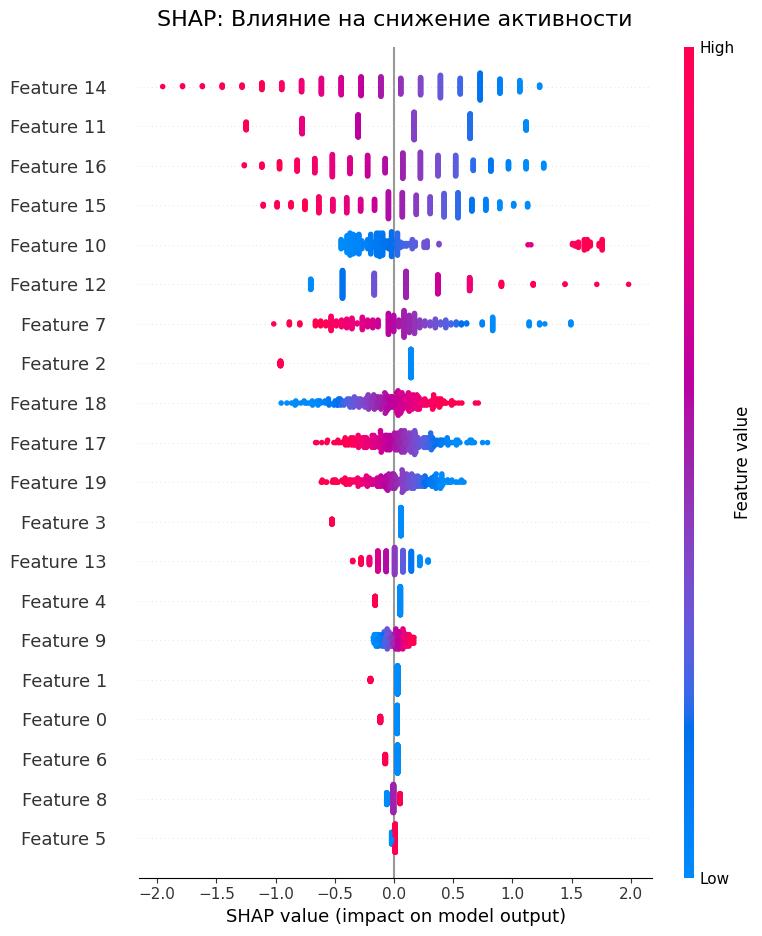

In [120]:
preprocessor = grid_r.best_estimator_.named_steps['preprocessor']
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
best_model = grid_r.best_estimator_.named_steps['models']

explainer = shap.LinearExplainer(best_model, X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

yticklabels = ['популярная_категория_Косметика и аксесуары', 'популярная_категория_Кухонная посуда', 
               'популярная_категория_Мелкая бытовая техника и электроника', 
               'популярная_категория_Техника для красоты и здоровья', 
               'популярная_категория_Товары для детей', 'ord__тип_сервиса', 
               'ord__разрешить_сообщать', 'num__маркет_актив_6_мес', 
               'num__маркет_актив_тек_мес', 'num__длительность']  

shap.summary_plot(shap_values, X_test_transformed, 
                  max_display=20, 
                  plot_type='dot',
                  show=False)
plt.gcf().suptitle('SHAP: Влияние на снижение активности', fontsize=16)
plt.tight_layout()
plt.show()

In [121]:
feature_mapping = {
    0: 'популярная_категория_Косметика и аксессуары',
    1: 'популярная_категория_Кухонная посуда', 
    2: 'популярная_категория_Мелкая бытовая техника и электроника',
    3: 'популярная_категория_Техника для красоты и здоровья',
    4: 'популярная_категория_Товары для детей',
    5: 'ord__тип_сервиса',
    6: 'ord__разрешить_сообщать',
    7: 'num__маркет_актив_6_мес',
    8: 'num__маркет_актив_тек_мес',
    9: 'num__длительность',
    10: 'num__акционные_покупки',
    11: 'num__средний_просмотр_категорий_за_визит',
    12: 'num__неоплаченные_продукты_штук_квартал',
    13: 'num__ошибка_сервиса',
    14: 'num__страниц_за_визит',
    15: 'num__время_текущий_месяц',
    16: 'num__время_предыдущий_месяц',
    17: 'num__деньги_текущий_месяц',
    18: 'num__деньги_предыдущий_месяц',
    19: 'num__деньги_препредыдущий_месяц'
}

importance = np.abs(shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature_index': range(len(importance)),
    'Название_признака': [feature_mapping.get(i, f'Feature_{i}') for i in range(len(importance))],
    'SHAP_importance': importance
}).sort_values('SHAP_importance', ascending=False).head(20)

print("ТОП-20 ПРИЗНАКОВ ПО ВАЖНОСТИ:")
print(feature_importance_df.round(4))

ТОП-20 ПРИЗНАКОВ ПО ВАЖНОСТИ:
    Feature_index                                  Название_признака  \
14             14                              num__страниц_за_визит   
11             11           num__средний_просмотр_категорий_за_визит   
16             16                        num__время_предыдущий_месяц   
15             15                           num__время_текущий_месяц   
10             10                             num__акционные_покупки   
12             12            num__неоплаченные_продукты_штук_квартал   
7               7                            num__маркет_актив_6_мес   
2               2  популярная_категория_Мелкая бытовая техника и ...   
18             18                       num__деньги_предыдущий_месяц   
17             17                          num__деньги_текущий_месяц   
19             19                    num__деньги_препредыдущий_месяц   
3               3  популярная_категория_Техника для красоты и здо...   
13             13                 

Сильнее всего влияют на параметр снижения покупательской активности действия покупателя, связанные с просмотром и посещением станиц интернет-магазина. Данные признаки положительно влияют на то, что покупательская активность данного клиента не снизится. ПРизнаки акционные покупки и неоплаченные покупки также сильно влияют на потребительскую активность, но говорят, наоборот, о ее снижении. Нужно рекомендовать маркетологам обращать внимание на данных клиентов.Признаки о категориях товаров, маркетинговая активность за последний месяц, тип сервиса, разрешение о сообщении мало влияют на покупательскую способность.  
В целом важность признаков, выделенная моделью, совпадает с тем, что было видно в исследовательском анализе. Важно для поддержания потребительской активности время, проведенное на сайте, количество просмотренных категорий, страниц. Негативно влияют наличие неоплаченных товаров в корзине, больше количество покупок по акции. Тип сервиса практически не влияет на потребительскую активность клиентов. Большое количество ошибок на сайте положительно влияет на отнесение к категории с сохраняющейся потребительской активностью, возможно, это связано с тем, что данные лица просто больше времени проводят на сайте/больше категорий товаров просматривают.
Рекомендуется улучшить информирование клиентов с неоплаченными товарами в корзине больше 2 о проводимых акциях, а также о самом товаре. Оставление неоплаченного товара в корзине может свидетельствовать либо о недостаточности информации о товаре, либо о том, что товар неполностью соответствует запросу, либо о потраченном бюджете на покупки. 

## Сегментация покупателей

Посмотрим на тестовой выборке как соотносится вероятности снижения покупательской активности, рассчитанные выбранной моделью, с другими параметрами.

In [122]:
y_proba = grid_r.predict_proba(X_test)[:, 1]
X_test_with_proba = X_test.copy()
X_test_with_proba['вероятность'] = y_proba

In [123]:
X_test_with_proba.head().T

,809,302,955,149,582
тип_сервиса,стандарт,премиум,премиум,премиум,стандарт
разрешить_сообщать,да,нет,да,да,нет
маркет_актив_6_мес,4.1,1.4,3.3,3.5,5.5
маркет_актив_тек_мес,4,4,4,3,4
длительность,606,684,488,1057,147
акционные_покупки,0.15,0.94,0.13,0.35,0.99
популярная_категория,Техника для красоты и здоровья,Товары для детей,Домашний текстиль,Домашний текстиль,Мелкая бытовая техника и электроника
средний_просмотр_категорий_за_визит,6,3,4,4,1
неоплаченные_продукты_штук_квартал,1,6,2,3,2
ошибка_сервиса,4,1,8,5,3


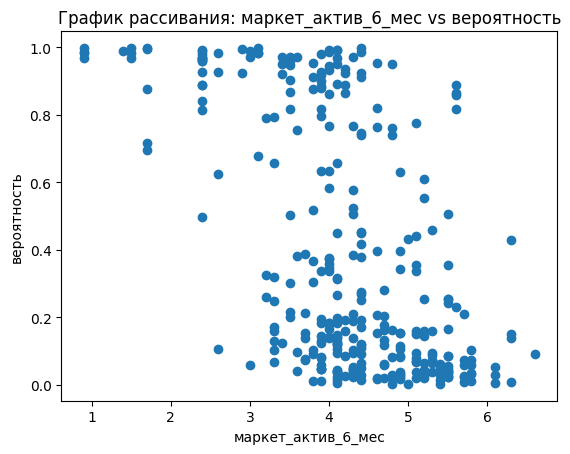

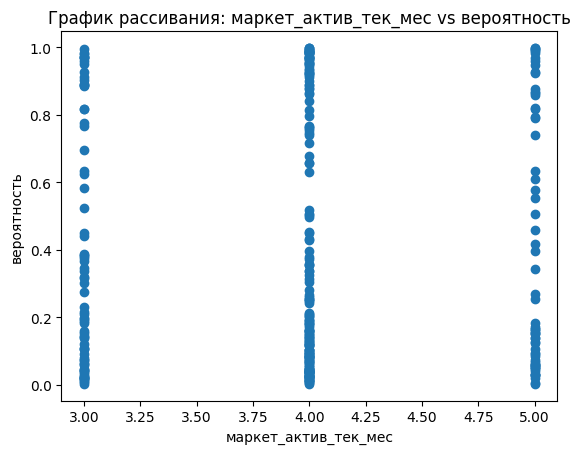

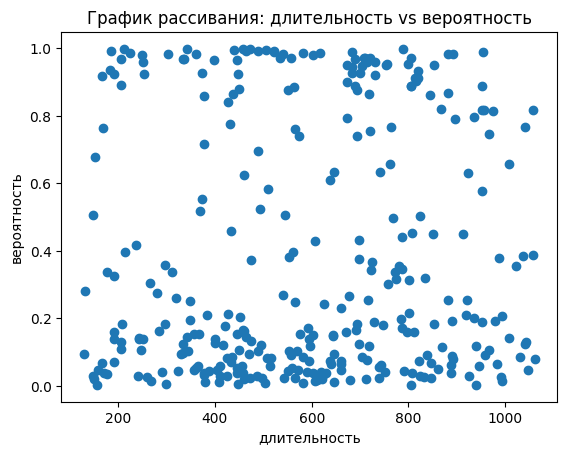

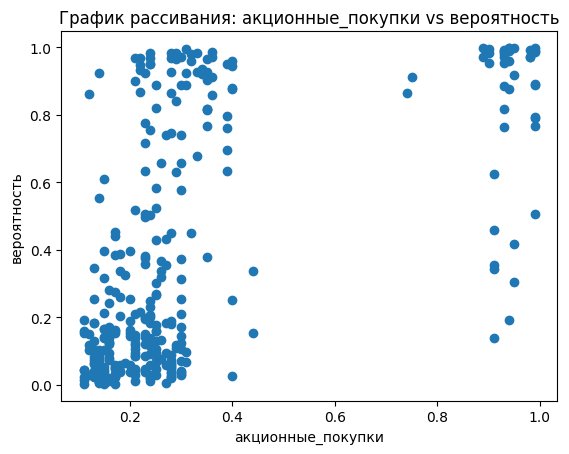

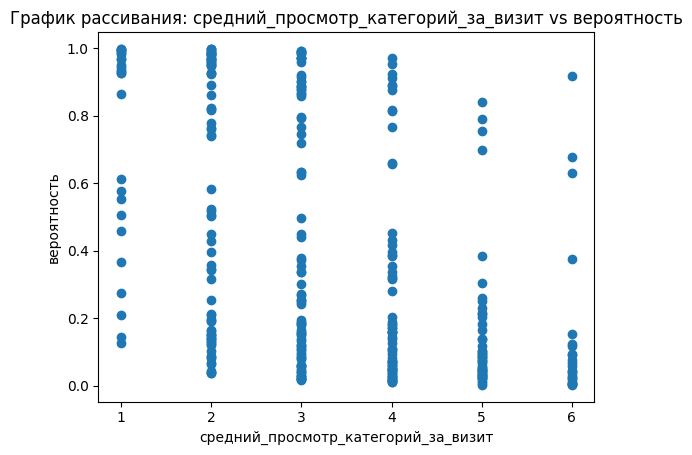

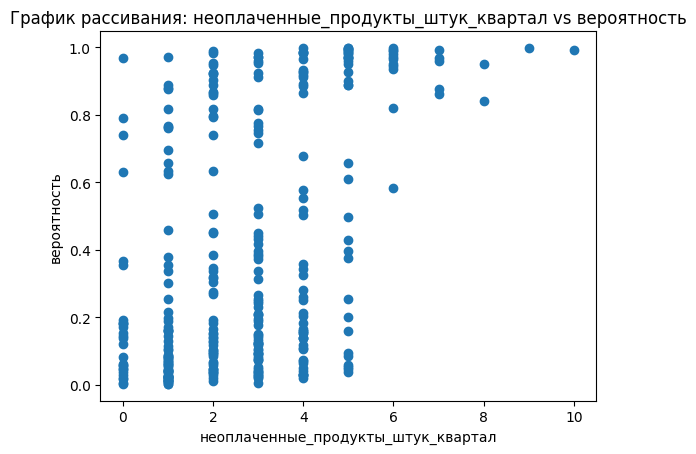

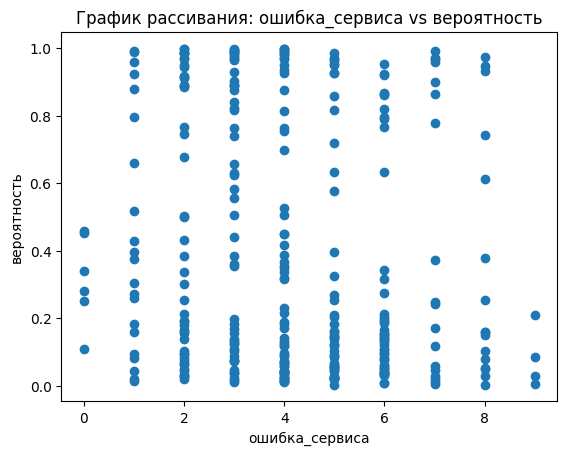

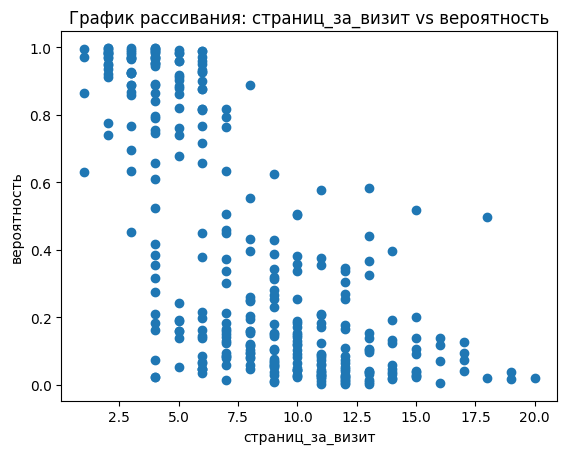

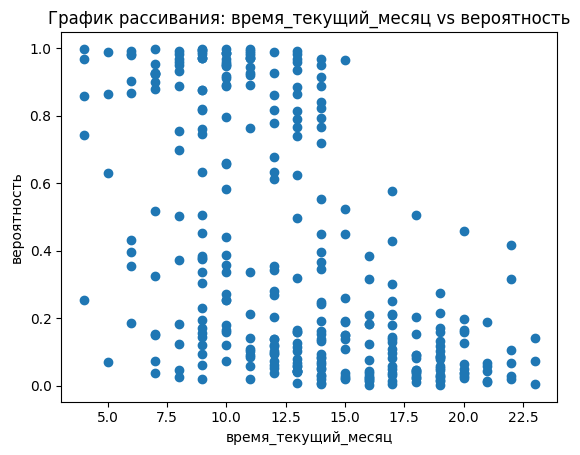

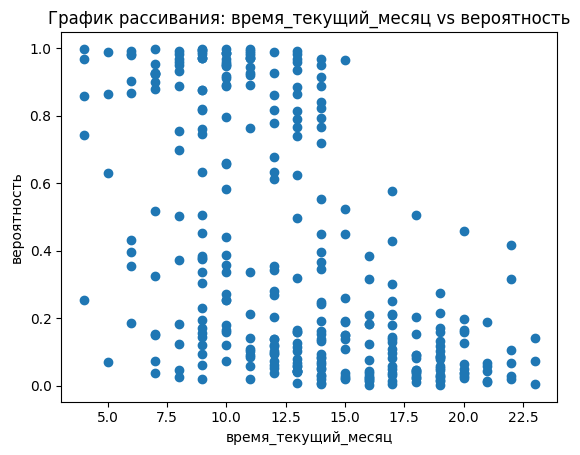

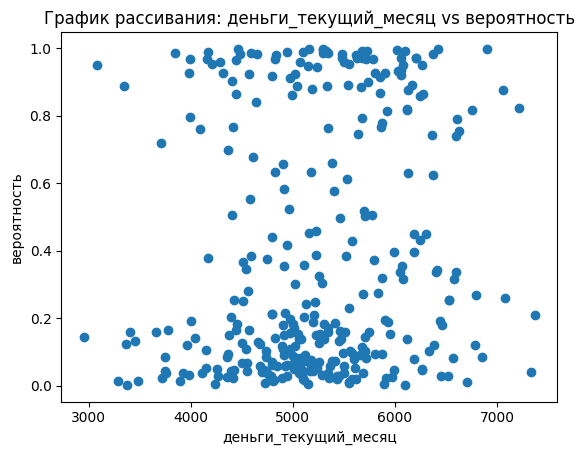

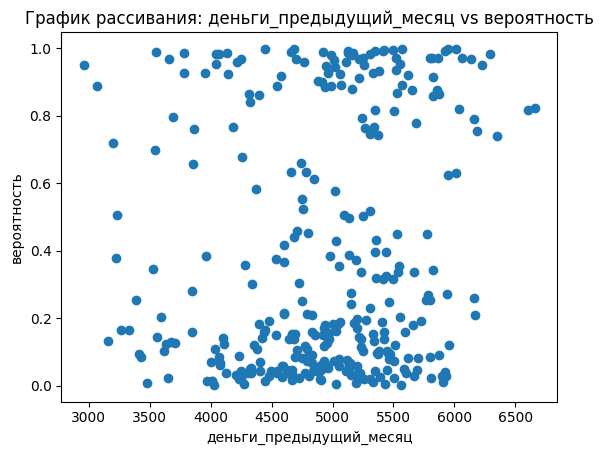

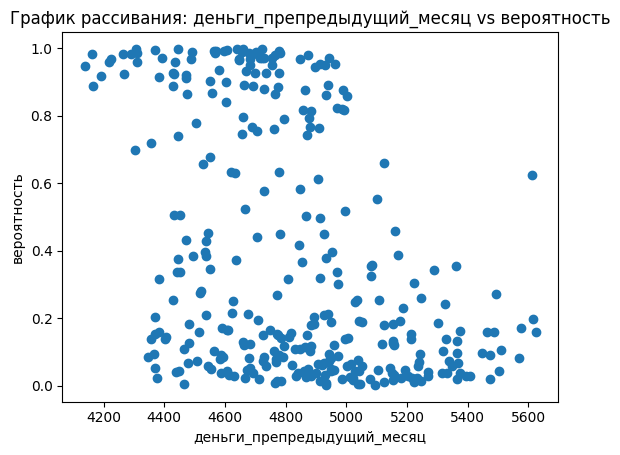

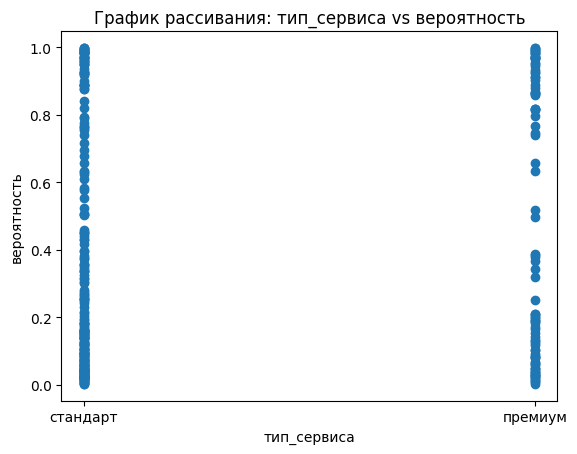

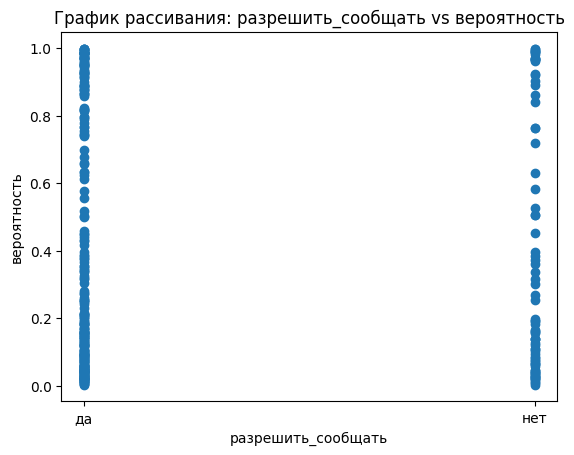

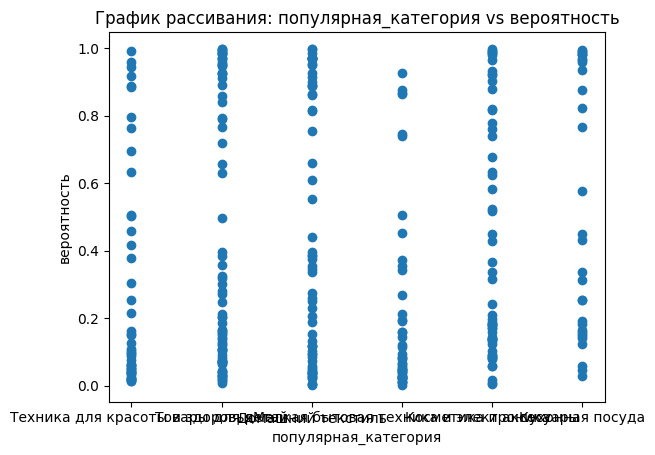

In [124]:
columns_to_plot = [
    'маркет_актив_6_мес',
    'маркет_актив_тек_мес',
    'длительность',
    'акционные_покупки',
    'средний_просмотр_категорий_за_визит',
    'неоплаченные_продукты_штук_квартал',
    'ошибка_сервиса',
    'страниц_за_визит',
    'время_текущий_месяц',
    'время_текущий_месяц',
    'деньги_текущий_месяц',
    'деньги_предыдущий_месяц',
    'деньги_препредыдущий_месяц',
    'тип_сервиса',
    'разрешить_сообщать',
    'популярная_категория'
]

for column in columns_to_plot:
    plt.scatter(X_test_with_proba[column], X_test_with_proba['вероятность'])  
    plt.title(f'График рассивания: {column} vs вероятность')  
    plt.xlabel(column)   
    plt.ylabel('вероятность')  
    plt.show()

Рассчитанные моделью вероятности подтверждают общие выводы, сделанные при анализе данных и при оценке важности отдельных признаков. При выделении отдельного сегмента для анализа потребительской активности клиентов я не стала бы брать признак выручки от клиента, поскольку он меняется на протяжении трех месяцев: сначала клиенты, сохраняющие потребительскую уверенность, в среднем платили больше, затем меньше и непонятно как анализировать (за прошедшие два месяца или за текущий). Предлагаю выбрать клиентов с большим количеством акционных товаров, данные признак существенно влияет на вероятность снижения потребительского поведения. Большое количество акционных товаров представляет из себя отдельных пик - можно уверенно провести границу от 0.6 товаров в корзине и выше. Предлагаю проанализировать данные клиентов, имеющих больше 0.6 товаров. Для этого составим графики  рассеяния с данными по клиентам с большим количеством акционных товаров и вероятностью снижения их покупательской активности. Также рассмотрим статистику по этому сегменту, предварительно присоединив данные по прибыли компании от каждого клиента.

In [125]:
X_test_with_proba_segment = X_test_with_proba[X_test_with_proba['акционные_покупки'] > 0.6]

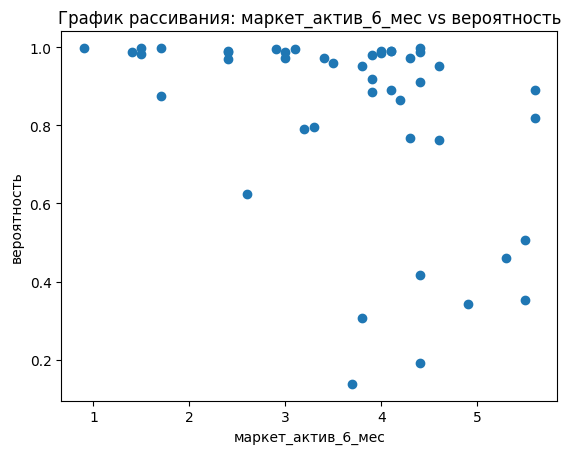

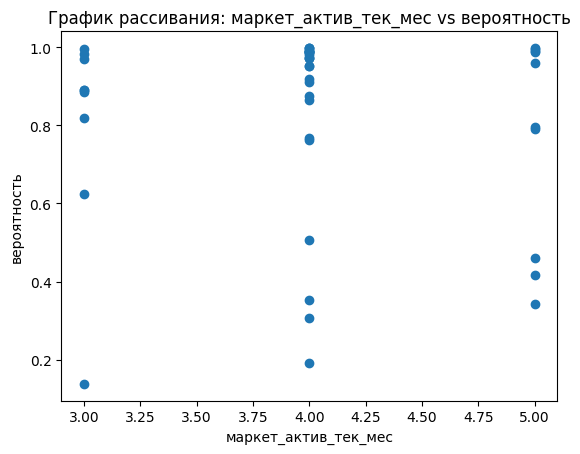

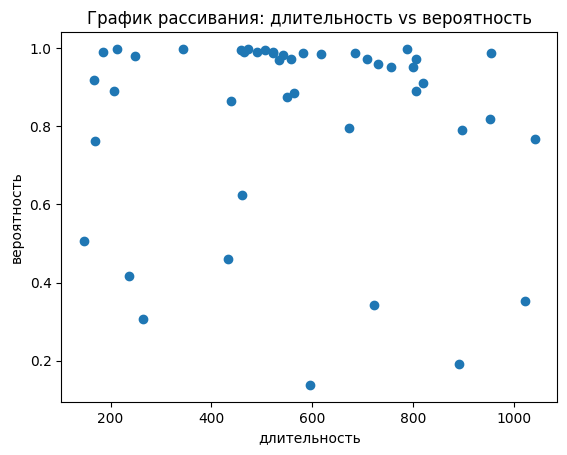

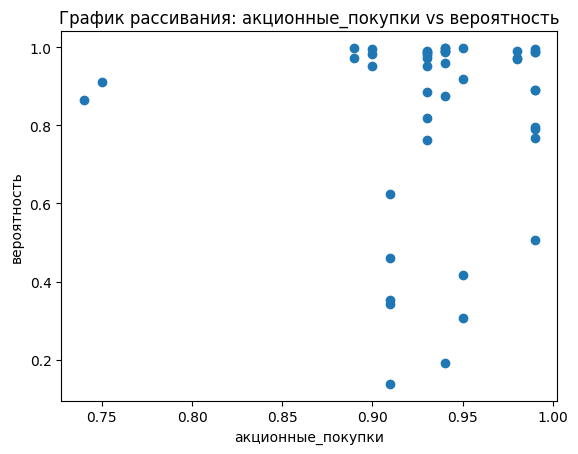

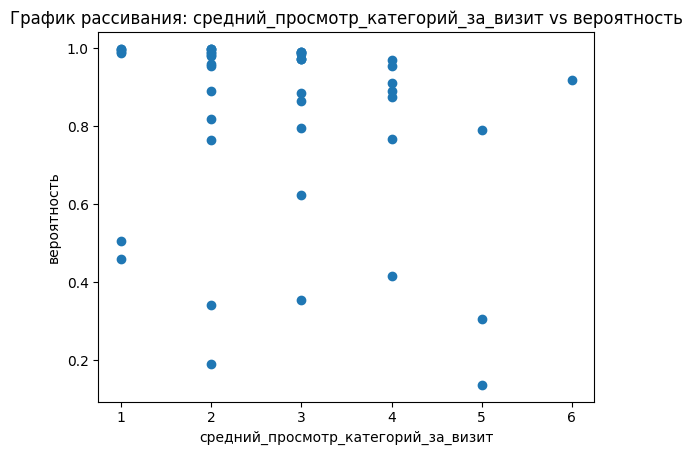

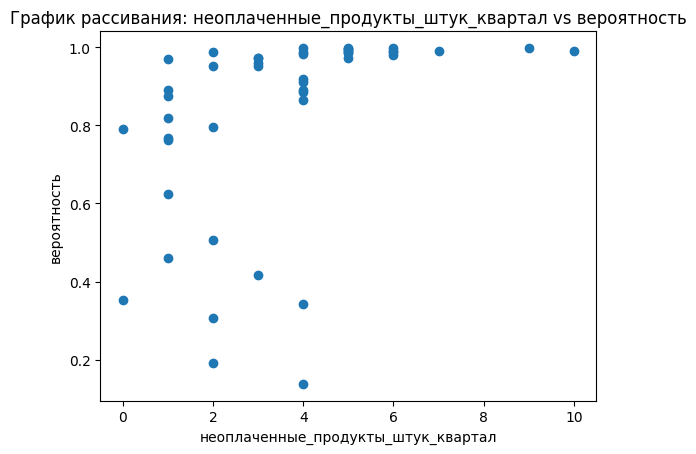

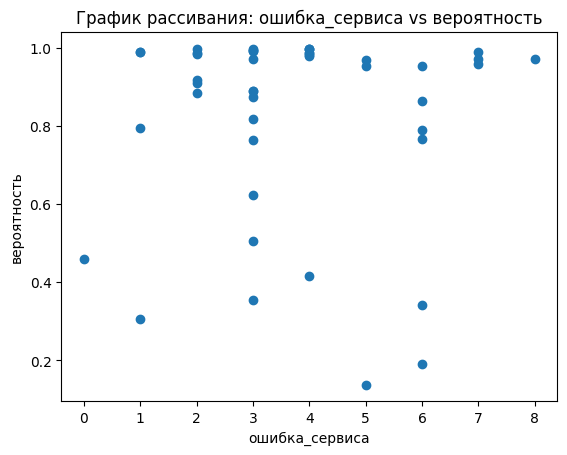

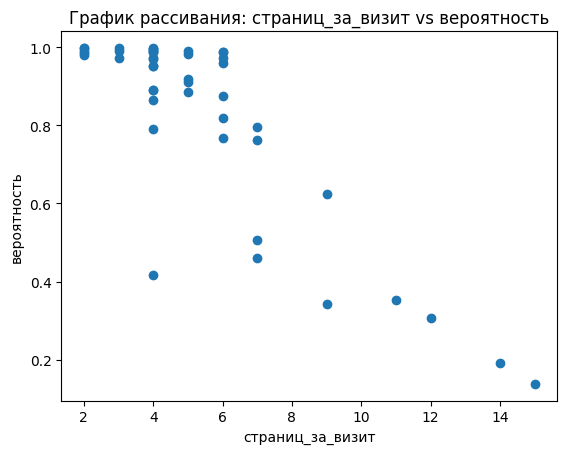

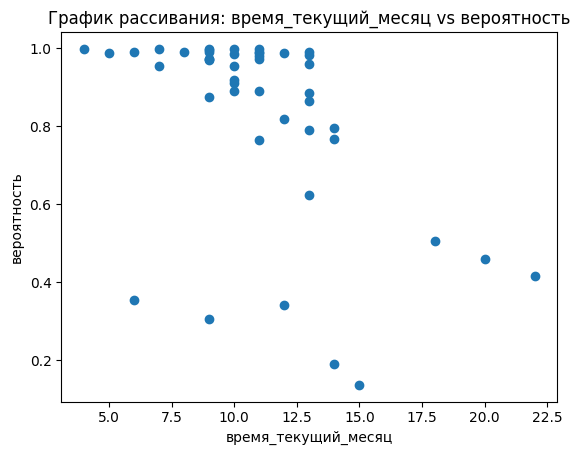

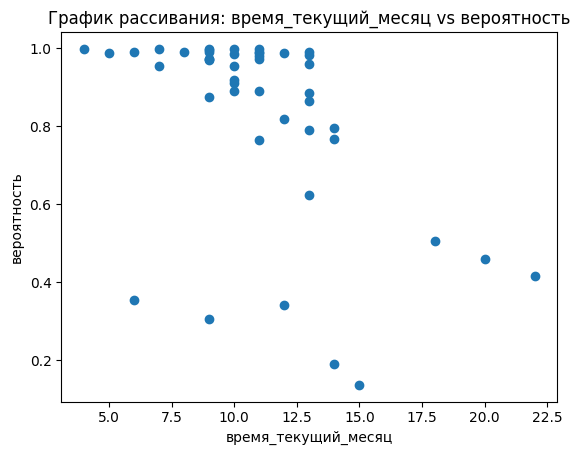

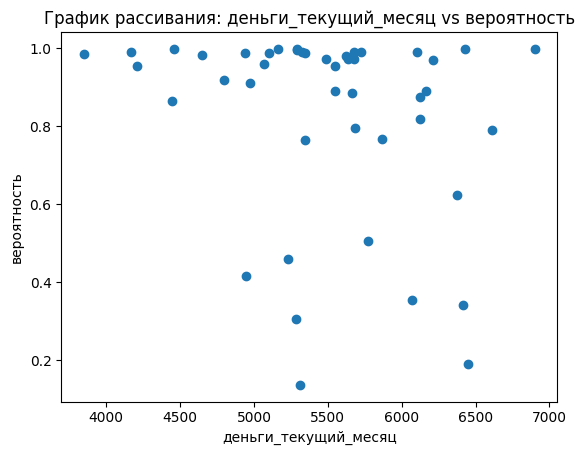

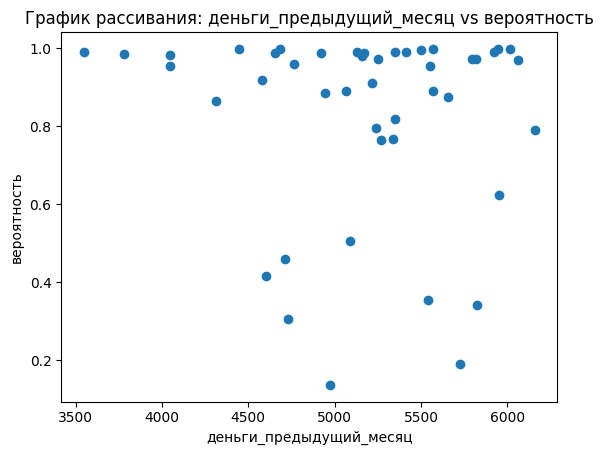

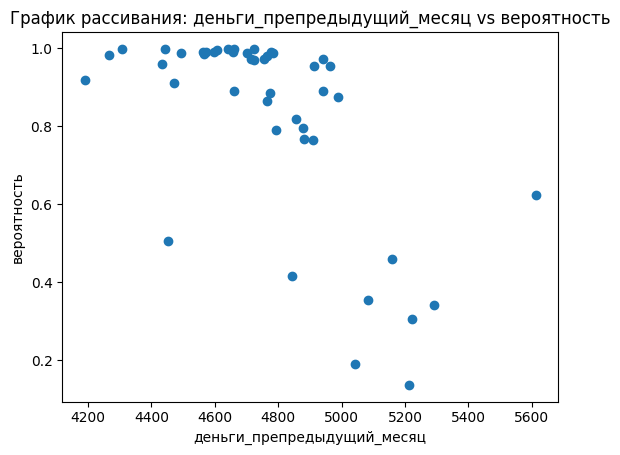

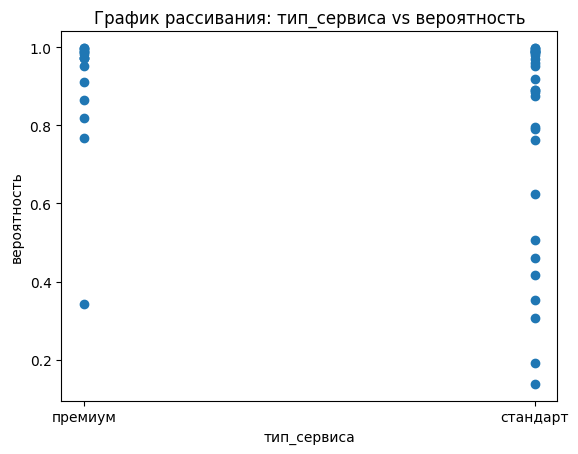

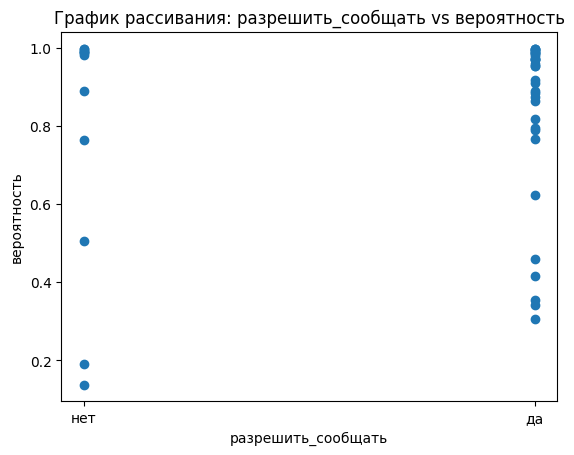

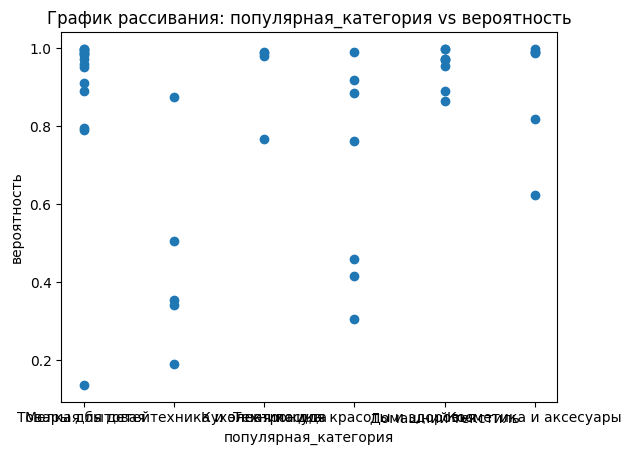

In [126]:
for column in columns_to_plot:
    plt.scatter(X_test_with_proba_segment[column], X_test_with_proba_segment['вероятность'])  
    plt.title(f'График рассивания: {column} vs вероятность')  
    plt.xlabel(column)   
    plt.ylabel('вероятность')  
    plt.show()

Проанализировав тестовую часть данных на связь между вероятностью снижения потребительской активностью с разными параметрами для выделенного сегмента (большое количество акционных товаров), можно отметить следующие:  
- сама по себе покупка акционных товаров не говорит о том, что потребительская активность снизится
- количество неоплаченных товаров больше 4 по прежнему резко негативный сигнал
- хотя наличие большого количества акционных товаров почти всегда говорит о снижении потребительской активности, но при потраченных денежных средствах больше среднего, признак потребительской активности начинает выравниваться  
- наличие примиума нейтральный фактор, вот возможность скорее негативный
- по любимым категориям домашний текстиль и кухонная посуда скорее положительный признак (остальные скорее отрицательный)  
- потраченное время, просмотренные страницы становятся нейтральным или положительным фактором, если они существенно больше нормы
В качестве рекомендаций данному сегменту покупателей можно рекомендовать делать больше акционных предложений (не все подойдут, но при большом количестве просмотров вероятность снижения покупательской активности уменьшается) на большие суммы (при потраченных денежных средствах больше среднего вероятность снижения покупательской активности также уменьшается). Можно сосредоточится на категориях домашний текстиль и кухонная посуда, но я бы не рекомендовала. Если клиенты уже приобрели по акциям товары этих категорий, то лучше предлагать другие.


In [127]:
market_file_money = pd.merge(market_file, money, on = 'id', how = 'left')

In [128]:
market_action = market_file_money[market_file_money['акционные_покупки'] > 0.6]

Статистка по всем клиентам с данными о прибыли компании от клиента

In [129]:
market_file_money.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1296.0,215999.464506,374.327860,215349.00,215675.750,215999.500,216323.250,216647.00
маркет_актив_6_мес,1296.0,4.256404,1.013525,0.90,3.700,4.200,4.900,6.60
маркет_актив_тек_мес,1296.0,4.009259,0.696316,3.00,4.000,4.000,4.000,5.00
длительность,1296.0,602.967593,249.195823,121.00,409.500,606.500,806.250,1079.00
акционные_покупки,1296.0,0.320069,0.249159,0.11,0.170,0.240,0.300,0.99
средний_просмотр_категорий_за_визит,1296.0,3.267747,1.355125,1.00,2.000,3.000,4.000,6.00
неоплаченные_продукты_штук_квартал,1296.0,2.841821,1.974074,0.00,1.000,3.000,4.000,10.00
ошибка_сервиса,1296.0,4.184414,1.951719,0.00,3.000,4.000,6.000,9.00
страниц_за_визит,1296.0,8.187500,3.978459,1.00,5.000,8.000,11.000,20.00
время_текущий_месяц,1296.0,13.210648,4.221794,4.00,10.000,13.000,16.000,23.00


Статистка по  клиентам  с большим количеством акционных покупок с данными о прибыли компании от клиента

In [130]:
market_action.describe().T

,count,mean,std,min,25%,50%,75%,max
id,166.0,215755.331325,384.152312,215349.00,215481.5000,215625.50,215843.50,216647.00
маркет_актив_6_мес,166.0,3.781928,1.078567,0.90,3.3000,4.00,4.40,5.70
маркет_актив_тек_мес,166.0,3.975904,0.704546,3.00,3.0000,4.00,4.00,5.00
длительность,166.0,604.054217,240.564293,147.00,436.5000,613.00,800.75,1064.00
акционные_покупки,166.0,0.942711,0.038414,0.74,0.9300,0.94,0.98,0.99
средний_просмотр_категорий_за_визит,166.0,2.807229,1.297623,1.00,2.0000,3.00,4.00,6.00
неоплаченные_продукты_штук_квартал,166.0,3.644578,2.479040,0.00,2.0000,3.00,5.00,10.00
ошибка_сервиса,166.0,4.132530,1.834161,0.00,3.0000,4.00,5.00,8.00
страниц_за_визит,166.0,5.710843,3.273512,1.00,3.0000,5.00,7.00,15.00
время_текущий_месяц,166.0,11.379518,3.644082,4.00,9.0000,11.00,13.00,22.00


Прибыль по покупателям с большим количеством акционных покупок чуть меньше, но это явно не настолько, чтобы попытаться сохранить данных клиентов. Обращает на себя внимание, что данные клиенты больше тратят время на просмотр страниц, но просматривают столько же категорий за визит.

## Общий вывод

Были рассмотрены данные за последние три месяца по работе интернет-магазина на предмет составления модели, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца. Была отобрана модель логистической регрессии - LogisticRegression(C=2, penalty='l1', solver='liblinear'). Проанализированы признаки максимально влияющие на снижение/неснижение покупательской активности.

Сильнее всего влияют на параметр снижения покупательской активности действия покупателя, связанные с просмотром и посещением станиц интернет-магазина. Данные признаки положительно влияют на то, что покупательская активность данного клиента не снизится. ПРизнаки акционные покупки и неоплаченные покупки также сильно влияют на потребительскую активность, но говорят, наоборот, о ее снижении. Нужно рекомендовать маркетологам обращать внимание на данных клиентов.Признаки о категориях товаров, маркетинговая активность за последний месяц, тип сервиса, разрешение о сообщении мало влияют на покупательскую способность

Корреляционный анализ данных показал ухудшение в текущем месяце корреляции маркетинговой деятельности с признаком потребительской активности.  ПРи этом признак покупательской активности значимо коррелирует с маркетинговой активностью за 6 месяцев. Либо маркетинговая деятельность не за текущий месяц еще не отразилась полностью на настроениях покупателей, либо в ней что-то изменилось (в последний месяц корреляция данного показателя практически сошла на нет, и это при сохранении практически на прежнем уровне маркетинговой активности).  

Проведенный анализ также показал значимую корреляцию целевого признака с просмотренными страницами за визит, временем посещения сайт, средним просмотром категорий за визит. Логически рассуждая, данные признаки и должны быть связаны: чтобы что-то купить, нужно найти товар, просмотреть по нему информацию, посмотреть похожие товары. При этом достаточно большое количество ошибок сервиса (но этот признак практически не влияет на снижение потребительской активности). 

Был выделен и проанализирован сегмент покупателей с большим количеством акционных товаров. Можно отметить следующие:  
- сама по себе покупка большого количества акционных товаров не говорит о том, что потребительская активность снизится  
- количество неоплаченных товаров больше 4 по прежнему резко негативный сигна  
- хотя наличие большого количества акционных товаров почти всегда говорит о снижении потребительской активности, но при потраченных денежных средствах больше среднего, признак потребительской активности начинает выравниваться
В качестве рекомендаций данному сегменту покупателей можно рекомендовать делать больше акционных предложений (не все подойдут, но при большом количестве просмотров вероятность снижения покупательской активности уменьшается) на большие суммы (при потраченных денежных средствах больше среднего вероятность снижения покупательской активности также уменьшается). Можно сосредоточится на категориях домашний текстиль и кухонная посуда, но я бы не рекомендовала. Если клиенты уже приобрели по акциям товары этих категорий, то лучше предлагать другие.